# Notebook 06 — Exploratory Data Analysis

## From Soundscapes to Biodiversity

This notebook performs exploratory data analysis on the cleaned acoustic and independent eBird observation datasets produced by the preceding data preparation and audio feature extraction workflows.

The analysis examines sampling coverage, geographic and temporal structure, recording characteristics, acoustic feature distributions, data-quality patterns, and relationships among acoustic descriptors. The resulting figures and structured JSON outputs are used both for the project website and as the exploratory foundation for subsequent statistical learning and modeling modules.

The analysis distinguishes between **dataset representation** and **ecological inference**. Xeno-canto recordings represent the selected acoustic sample, while eBird observations provide an independent observation-based reference. Neither dataset is treated as a direct estimate of regional biodiversity without accounting for its sampling process.

In [1]:
# ============================================================
# 1. Imports and project configuration
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Python environment ready.")

Python environment ready.


In [2]:
# ============================================================
# Shared plot styling — defined early so every figure,
# including Figure 01, can use it
# ============================================================

EDA_STYLE = {
    "background": "#07110f",
    "foreground": "#f2ebdd",
    "gold": "#d8b76a",
    "cyan": "#6ed6d1",
    "coral": "#e88b72",
    "grid": "#2a3530",
}


In [3]:
# ============================================================
# 2. Locate project root
# ============================================================

def find_project_root(marker="README.md"):
    p = Path.cwd().resolve()

    while not (p / marker).exists():
        if p.parent == p:
            raise RuntimeError(
                f"Could not find {marker} above {Path.cwd()}"
            )
        p = p.parent

    return p


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
EDA_FIGURES_DIR = FIGURES_DIR / "eda"
WEBSITE_DATA_DIR = (
    PROJECT_ROOT / "website" / "public" / "data"
)

EDA_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

WEBSITE_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data:")
print(PROCESSED_DIR)

print("\nEDA figures:")
print(EDA_FIGURES_DIR)

print("\nWebsite data:")
print(WEBSITE_DATA_DIR)

Project root:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity

Processed data:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\processed

EDA figures:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda

Website data:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\website\public\data


In [4]:
print("Processed directory:")
print(PROCESSED_DIR)

print("\nFiles currently available:")
for path in sorted(PROCESSED_DIR.iterdir()):
    print(
        f"{path.name:45} "
        f"{'DIR' if path.is_dir() else 'FILE'}"
    )

Processed directory:
C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\processed

Files currently available:
.gitkeep                                      FILE
acoustic_features_recording.csv               FILE
acoustic_features_window.csv                  FILE
cleaning_summary.csv                          FILE
ebird_observations.csv                        FILE
master_metadata.csv                           FILE


In [5]:
# ============================================================
# 3. Load analysis-ready datasets
# ============================================================

FEATURES_PATH = (
    PROCESSED_DIR / "acoustic_features_recording.csv"
)

WINDOW_FEATURES_PATH = (
    PROCESSED_DIR / "acoustic_features_window.csv"
)

EBIRD_PATH = (
    PROCESSED_DIR / "ebird_observations.csv"
)

MASTER_METADATA_PATH = (
    PROCESSED_DIR / "master_metadata.csv"
)

features = pd.read_csv(FEATURES_PATH)
window_features = pd.read_csv(WINDOW_FEATURES_PATH)
ebird = pd.read_csv(EBIRD_PATH)
master_metadata = pd.read_csv(MASTER_METADATA_PATH)

print("Acoustic recording-level features:")
print(features.shape)

print("\nAcoustic window-level features:")
print(window_features.shape)

print("\neBird observations:")
print(ebird.shape)

print("\nMaster metadata:")
print(master_metadata.shape)

Acoustic recording-level features:
(275, 114)

Acoustic window-level features:
(1179, 69)

eBird observations:
(1326, 32)

Master metadata:
(275, 41)


In [6]:
# ============================================================
# 5. Validate recording-level provenance
# ============================================================

print("RECORDING-LEVEL PROVENANCE CHECK")
print("=" * 60)

print("Feature rows:", len(features))
print(
    "Unique feature recording IDs:",
    features["recording_id"].nunique()
)

print("Master metadata rows:", len(master_metadata))
print(
    "Unique master recording IDs:",
    master_metadata["recording_id"].nunique()
)

# Basic uniqueness checks
assert len(features) == 275
assert features["recording_id"].nunique() == 275

assert len(master_metadata) == 275
assert master_metadata["recording_id"].nunique() == 275

# Check that the two recording ID sets are identical
feature_ids = set(features["recording_id"])
metadata_ids = set(master_metadata["recording_id"])

print("\nIDs in features but not metadata:")
print(sorted(feature_ids - metadata_ids))

print("\nIDs in metadata but not features:")
print(sorted(metadata_ids - feature_ids))

assert feature_ids == metadata_ids

print("\n✓ 275 unique recording IDs confirmed.")
print("✓ Feature and metadata recording IDs match exactly.")

RECORDING-LEVEL PROVENANCE CHECK
Feature rows: 275
Unique feature recording IDs: 275
Master metadata rows: 275
Unique master recording IDs: 275

IDs in features but not metadata:
[]

IDs in metadata but not features:
[]

✓ 275 unique recording IDs confirmed.
✓ Feature and metadata recording IDs match exactly.


In [7]:
# ============================================================
# 6. Validate state and species structure
# ============================================================

expected_states = {"CA", "AZ", "TX"}

observed_states = set(
    features["state"].dropna().unique()
)

print("OBSERVED STATES")
print("=" * 60)
print(sorted(observed_states))

assert observed_states == expected_states

print("\nRECORDINGS BY STATE")
print("-" * 40)

recordings_by_state = (
    features["state"]
    .value_counts()
    .sort_index()
)

print(recordings_by_state)

print("\nUNIQUE SPECIES BY STATE")
print("-" * 40)

species_by_state = (
    features
    .groupby("state")["species_id"]
    .nunique()
    .sort_index()
)

print(species_by_state)

print("\nTOTAL UNIQUE SPECIES")
print("-" * 40)

total_species = features["species_id"].nunique()

print(total_species)

assert total_species == 159

print("\n✓ State structure confirmed.")
print("✓ 159 represented Xeno-canto species confirmed.")

OBSERVED STATES
['AZ', 'CA', 'TX']

RECORDINGS BY STATE
----------------------------------------
state
AZ     75
CA    100
TX    100
Name: count, dtype: int64

UNIQUE SPECIES BY STATE
----------------------------------------
state
AZ     44
CA     66
TX    100
Name: species_id, dtype: int64

TOTAL UNIQUE SPECIES
----------------------------------------
159

✓ State structure confirmed.
✓ 159 represented Xeno-canto species confirmed.


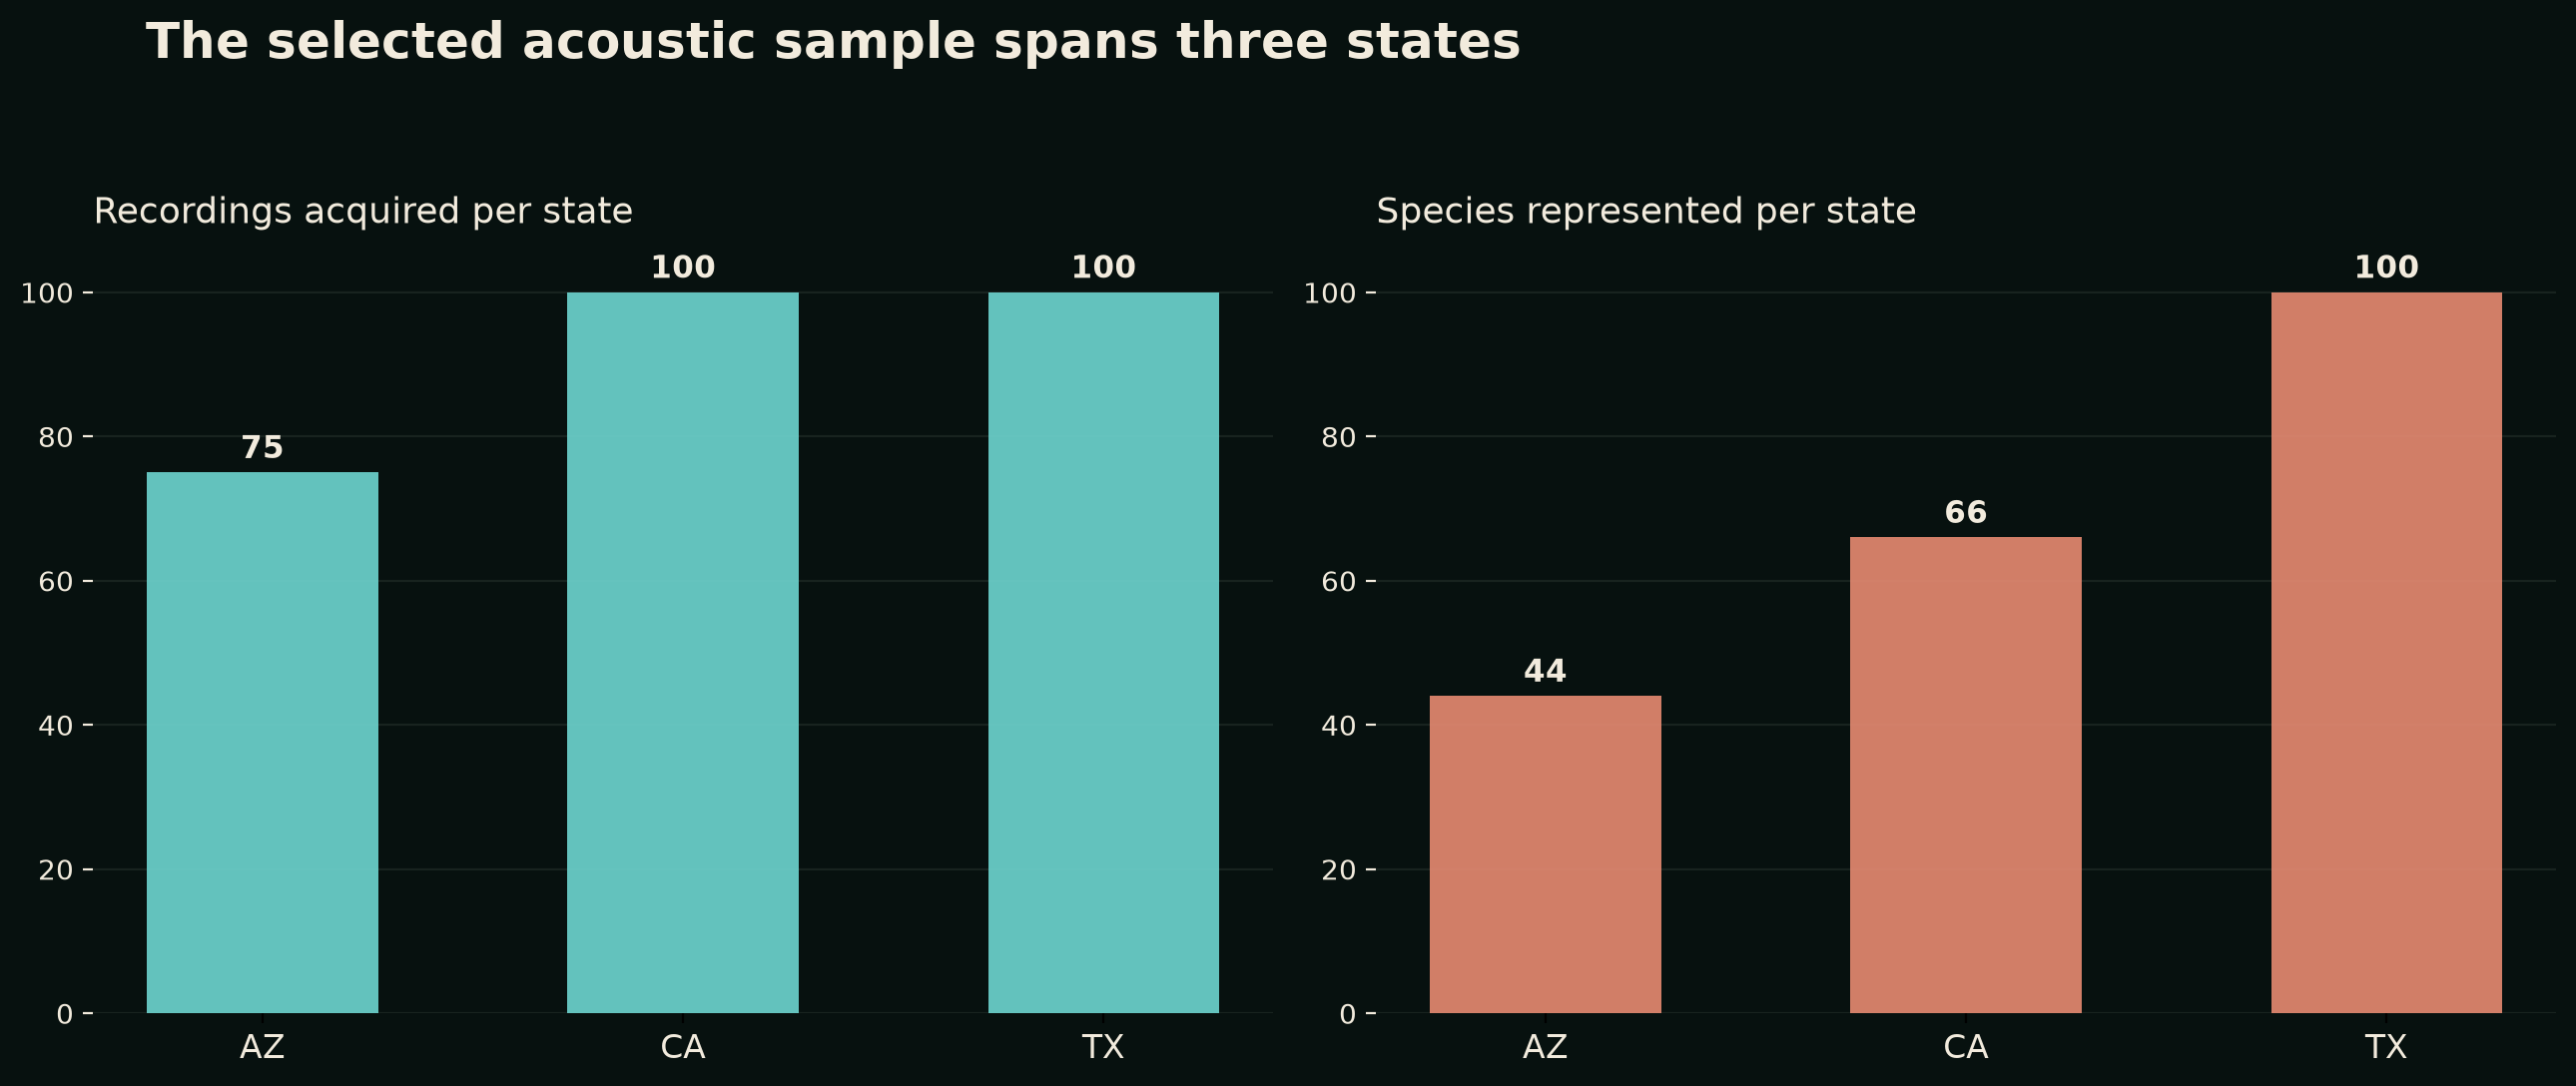

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\01_recordings_by_state.png


In [8]:
# ============================================================
# Figure 01 — Recordings and species by state
# ============================================================

fig01_summary = (
    features
    .groupby("state")
    .agg(
        recordings=("recording_id", "nunique"),
        species=("species_id", "nunique")
    )
    .loc[["AZ", "CA", "TX"]]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=200)
fig.patch.set_facecolor(EDA_STYLE["background"])

x = np.arange(3)
labels = fig01_summary.index.tolist()

for ax, col, title, color in zip(
    axes,
    ["recordings", "species"],
    ["Recordings acquired per state", "Species represented per state"],
    [EDA_STYLE["cyan"], EDA_STYLE["coral"]]
):
    ax.set_facecolor(EDA_STYLE["background"])
    bars = ax.bar(x, fig01_summary[col], color=color, alpha=0.9, width=0.55)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=EDA_STYLE["foreground"], fontsize=12)
    ax.tick_params(axis="y", colors=EDA_STYLE["foreground"])
    ax.grid(axis="y", color=EDA_STYLE["grid"], alpha=0.5)
    ax.set_axisbelow(True)
    ax.set_title(title, color=EDA_STYLE["foreground"], fontsize=13, loc="left", pad=12)
    for bar, val in zip(bars, fig01_summary[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1, str(int(val)),
                ha="center", va="bottom", color=EDA_STYLE["foreground"], fontsize=11, fontweight="bold")

fig.suptitle("The selected acoustic sample spans three states",
             fontsize=18, fontweight="bold", color=EDA_STYLE["foreground"], x=0.06, ha="left")

plt.tight_layout(rect=[0, 0, 1, 0.92])

figure_path = EDA_FIGURES_DIR / "01_recordings_by_state.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved:", figure_path)


**Figure interpretation.** The acquisition target of 100 California, 75 Arizona, and 100 Texas recordings was met exactly, while species representation varies by state (66 in California, 44 in Arizona, 100 in Texas) despite comparable or smaller sample sizes. This asymmetry motivates the acoustic-versus-independent-observation comparison in the following figure.

In [9]:
# ============================================================
# 7. Validate species provenance
# ============================================================

species_check = (
    features[
        ["recording_id", "species_id"]
    ]
    .merge(
        master_metadata[
            ["recording_id", "species_id"]
        ],
        on="recording_id",
        how="outer",
        suffixes=("_features", "_metadata"),
        indicator=True
    )
)

print("MERGE STATUS")
print("=" * 60)
print(species_check["_merge"].value_counts())

assert (species_check["_merge"] == "both").all()

species_match = (
    species_check["species_id_features"]
    == species_check["species_id_metadata"]
)

print("\nSpecies IDs matching:")
print(
    f"{species_match.sum()} / {len(species_match)}"
)

assert species_match.all()

print("\n✓ Species provenance confirmed.")

MERGE STATUS
_merge
both          275
left_only       0
right_only      0
Name: count, dtype: int64

Species IDs matching:
275 / 275

✓ Species provenance confirmed.


In [10]:
# ============================================================
# 8. Missingness audit
# ============================================================

print("RECORDING-LEVEL FEATURES — MISSINGNESS")
print("=" * 60)

missingness_features = (
    features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_features_nonzero = missingness_features[
    missingness_features > 0
]

if len(missing_features_nonzero) == 0:
    print("No missing values found in the recording-level feature table.")
else:
    print("Columns containing missing values:")
    print(missing_features_nonzero)

print(
    "\nTotal missing cells:",
    int(features.isna().sum().sum())
)


print("\nWINDOW-LEVEL FEATURES — MISSINGNESS")
print("=" * 60)

missingness_windows = (
    window_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_windows_nonzero = missingness_windows[
    missingness_windows > 0
]

if len(missing_windows_nonzero) == 0:
    print("No missing values found in the window-level feature table.")
else:
    print("Columns containing missing values:")
    print(missing_windows_nonzero)

print(
    "\nTotal missing cells:",
    int(window_features.isna().sum().sum())
)


print("\neBIRD — MISSINGNESS")
print("=" * 60)

missingness_ebird = (
    ebird
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_ebird_nonzero = missingness_ebird[
    missingness_ebird > 0
]

if len(missing_ebird_nonzero) == 0:
    print("No missing values found in the eBird table.")
else:
    print("Columns containing missing values:")
    print(missing_ebird_nonzero)

print(
    "\nTotal missing cells:",
    int(ebird.isna().sum().sum())
)

RECORDING-LEVEL FEATURES — MISSINGNESS
Columns containing missing values:
mfcc_13_within_std_std           117
mfcc_13_between_window_std       117
mfcc_05_within_std_std           117
mfcc_05_between_window_std       117
mfcc_12_within_std_std           117
mfcc_12_between_window_std       117
mfcc_11_within_std_std           117
mfcc_11_between_window_std       117
mfcc_10_within_std_std           117
mfcc_10_between_window_std       117
mfcc_09_within_std_std           117
mfcc_09_between_window_std       117
mfcc_08_within_std_std           117
mfcc_08_between_window_std       117
mfcc_07_within_std_std           117
mfcc_07_between_window_std       117
mfcc_06_within_std_std           117
mfcc_06_between_window_std       117
spectral_centroid_mean_std       117
spectral_centroid_std_std        117
spectral_bandwidth_mean_std      117
spectral_bandwidth_std_std       117
spectral_rolloff_mean_std        117
spectral_rolloff_std_std         117
mfcc_01_between_window_std       117
m

In [11]:
# ============================================================
# 8A. Characterize missingness patterns
# ============================================================

feature_missing = (
    features.isna().sum()
    .sort_values(ascending=False)
)

print("Columns with missing values:")
print(
    feature_missing[
        feature_missing > 0
    ].to_string()
)

print("\nTotal missing cells:")
print(
    int(features.isna().sum().sum())
)

print("\nRows containing any missing value:")
print(
    int(features.isna().any(axis=1).sum())
)

print("\nRows containing no missing values:")
print(
    int(features.notna().all(axis=1).sum())
)

Columns with missing values:
mfcc_13_within_std_std           117
mfcc_13_between_window_std       117
mfcc_05_within_std_std           117
mfcc_05_between_window_std       117
mfcc_12_within_std_std           117
mfcc_12_between_window_std       117
mfcc_11_within_std_std           117
mfcc_11_between_window_std       117
mfcc_10_within_std_std           117
mfcc_10_between_window_std       117
mfcc_09_within_std_std           117
mfcc_09_between_window_std       117
mfcc_08_within_std_std           117
mfcc_08_between_window_std       117
mfcc_07_within_std_std           117
mfcc_07_between_window_std       117
mfcc_06_within_std_std           117
mfcc_06_between_window_std       117
spectral_centroid_mean_std       117
spectral_centroid_std_std        117
spectral_bandwidth_mean_std      117
spectral_bandwidth_std_std       117
spectral_rolloff_mean_std        117
spectral_rolloff_std_std         117
mfcc_01_between_window_std       117
mfcc_01_within_std_std           117
mfcc_02_b

In [12]:
# ============================================================
# 8C. Confirm structural missingness from window counts
# ============================================================

# Count analysis windows for each recording
window_counts = (
    window_features
    .groupby("recording_id")
    .size()
    .rename("n_windows")
)

# Join window counts to recording-level features
missingness_check = features[
    ["recording_id"]
].merge(
    window_counts,
    on="recording_id",
    how="left"
)

# Determine whether the recording has exactly one analysis window
missingness_check["single_window"] = (
    missingness_check["n_windows"] == 1
)

# Determine whether any recording-level feature is missing
missingness_check["has_missing"] = (
    features.isna().any(axis=1).values
)

print("MISSINGNESS × WINDOW COUNT")
print("=" * 60)

check = pd.crosstab(
    missingness_check["single_window"],
    missingness_check["has_missing"],
    rownames=["single_window"],
    colnames=["has_missing"]
)

print(check)

print("\nWindow-count distribution:")
print(
    missingness_check["n_windows"]
    .value_counts()
    .sort_index()
)

print("\nSummary:")
print(
    "Single-window recordings:",
    int(missingness_check["single_window"].sum())
)

print(
    "Multi-window recordings:",
    int((~missingness_check["single_window"]).sum())
)

print(
    "Recordings with missing values:",
    int(missingness_check["has_missing"].sum())
)

MISSINGNESS × WINDOW COUNT
has_missing    False  True 
single_window              
False            158      0
True               0    117

Window-count distribution:
n_windows
1     117
2      39
3      25
4      22
5      15
6      12
7       7
8       5
9       1
10      4
11      5
12      2
13      1
14      2
15      3
16      3
17      1
18      1
19      1
20      1
21      1
22      1
23      2
30      1
31      1
35      1
64      1
Name: count, dtype: int64

Summary:
Single-window recordings: 117
Multi-window recordings: 158
Recordings with missing values: 117


In [13]:
# ============================================================
# 9. Create EDA analysis view
# ============================================================

# Start from the original recording-level dataset.
# n_windows is already present in this dataset.
features_eda = features.copy()

# Explicit recording-level sampling indicator
features_eda["single_window"] = (
    features_eda["n_windows"] == 1
)

print("EDA dataset shape:")
print(features_eda.shape)

print("\nWindow coverage:")
print(
    features_eda["n_windows"]
    .value_counts()
    .sort_index()
)

print("\nSingle-window recordings:")
print(
    features_eda["single_window"].value_counts()
)

print("\nMissing values:")
print(
    int(features_eda.isna().sum().sum())
)

EDA dataset shape:
(275, 115)

Window coverage:
n_windows
1     117
2      39
3      25
4      22
5      15
6      12
7       7
8       5
9       1
10      4
11      5
12      2
13      1
14      2
15      3
16      3
17      1
18      1
19      1
20      1
21      1
22      1
23      2
30      1
31      1
35      1
64      1
Name: count, dtype: int64

Single-window recordings:
single_window
False    158
True     117
Name: count, dtype: int64

Missing values:
5850


In [14]:
# ============================================================
# 9B. Validate stored n_windows against window-level data
# ============================================================

window_counts_check = (
    window_features
    .groupby("recording_id")
    .size()
    .rename("n_windows_from_windows")
)

n_windows_check = (
    features[["recording_id", "n_windows"]]
    .merge(
        window_counts_check,
        on="recording_id",
        how="outer"
    )
)

n_windows_check["match"] = (
    n_windows_check["n_windows"]
    == n_windows_check["n_windows_from_windows"]
)

print("n_windows validation")
print("=" * 60)

print(
    "Matching recordings:",
    int(n_windows_check["match"].sum())
)

print(
    "Mismatching recordings:",
    int((~n_windows_check["match"]).sum())
)

print(
    "Missing window-level counts:",
    int(
        n_windows_check["n_windows_from_windows"].isna().sum()
    )
)

if (~n_windows_check["match"]).any():
    print("\nMismatches:")
    display(
        n_windows_check.loc[
            ~n_windows_check["match"]
        ]
    )
else:
    print("\nAll recording-level n_windows values match the window-level data.")

n_windows validation
Matching recordings: 275
Mismatching recordings: 0
Missing window-level counts: 0

All recording-level n_windows values match the window-level data.


In [15]:
# ============================================================
# 10. eBird data audit
# ============================================================

print("eBIRD DATASET")
print("=" * 60)

print("Rows:", len(ebird))
print("Columns:", len(ebird.columns))

print("\nColumns:")
print(ebird.columns.tolist())

print("\nFirst five rows:")
display(ebird.head())

eBIRD DATASET
Rows: 1326
Columns: 32

Columns:
['state', 'species_code', 'common_name', 'scientific_name', 'location_id', 'location_name', 'observation_datetime', 'how_many', 'latitude', 'longitude', 'observation_valid', 'observation_reviewed', 'location_private', 'submission_id', 'observation_datetime_original', 'observation_date', 'year', 'month', 'day_of_year', 'hour', 'minute', 'has_observation_time', 'season', 'coordinate_valid', 'state_bbox_match', 'geographic_note', 'flag_missing_count', 'flag_missing_time', 'flag_pelagic', 'flag_any', 'cleaning_action', 'cleaning_reason']

First five rows:


,state,species_code,common_name,scientific_name,location_id,location_name,observation_datetime,how_many,latitude,longitude,...,season,coordinate_valid,state_bbox_match,geographic_note,flag_missing_count,flag_missing_time,flag_pelagic,flag_any,cleaning_action,cleaning_reason
0,CA,leasan,Least Sandpiper,Calidris minutilla,L509037,Morro Bay--Audubon overlook,2026-09-19 10:02:00,1.0,35.331648,-120.838333,...,Fall,True,True,NaN,False,False,False,False,KEEP,Valid eBird observation
1,CA,normoc,Northern Mockingbird,Mimus polyglottos,L509037,Morro Bay--Audubon overlook,2026-09-19 10:02:00,1.0,35.331648,-120.838333,...,Fall,True,True,NaN,False,False,False,False,KEEP,Valid eBird observation
2,CA,calthr,California Thrasher,Toxostoma redivivum,L509037,Morro Bay--Audubon overlook,2026-09-19 10:02:00,1.0,35.331648,-120.838333,...,Fall,True,True,NaN,False,False,False,False,KEEP,Valid eBird observation
3,CA,belkin1,Belted Kingfisher,Megaceryle alcyon,L53117291,"Arastradero Lake, Palo Alto US-CA 37.38182, -1...",2026-09-19 10:00:00,1.0,37.381815,-122.176246,...,Fall,True,True,NaN,False,False,False,False,KEEP,Valid eBird observation
4,CA,oaktit,Oak Titmouse,Baeolophus inornatus,L28362392,"315 E Miramar Ave, Claremont US-CA 34.12918, -...",2026-09-19 09:59:00,1.0,34.129179,-117.710442,...,Fall,True,True,NaN,False,False,False,False,KEEP,Valid eBird observation


In [16]:
# ============================================================
# 11. eBird missingness and quality audit
# ============================================================

print("eBIRD MISSINGNESS AUDIT")
print("=" * 60)

ebird_missing = (
    ebird
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Columns containing missing values:")
print(
    ebird_missing[ebird_missing > 0].to_string()
)

print("\nTotal missing cells:")
print(
    int(ebird.isna().sum().sum())
)

print("\nFlag counts:")
for col in [
    "flag_missing_count",
    "flag_missing_time",
    "flag_pelagic",
    "flag_any"
]:
    if col in ebird.columns:
        print(f"\n{col}:")
        print(
            ebird[col].value_counts(dropna=False)
        )

print("\nCleaning actions:")
print(
    ebird["cleaning_action"]
    .value_counts(dropna=False)
)

print("\nCleaning reasons:")
print(
    ebird["cleaning_reason"]
    .value_counts(dropna=False)
)

eBIRD MISSINGNESS AUDIT
Columns containing missing values:
geographic_note         1323
how_many                  16
hour                       1
observation_datetime       1
minute                     1

Total missing cells:
1342

Flag counts:

flag_missing_count:
flag_missing_count
False    1310
True       16
Name: count, dtype: int64

flag_missing_time:
flag_missing_time
False    1325
True        1
Name: count, dtype: int64

flag_pelagic:
flag_pelagic
False    1323
True        3
Name: count, dtype: int64

flag_any:
flag_any
False    1306
True       20
Name: count, dtype: int64

Cleaning actions:
cleaning_action
KEEP    1326
Name: count, dtype: int64

Cleaning reasons:
cleaning_reason
Valid eBird observation                         1306
Retained with documented metadata limitation      20
Name: count, dtype: int64


In [17]:
# ============================================================
# 12. eBird species and observation structure
# ============================================================

print("eBIRD SPECIES STRUCTURE")
print("=" * 60)

# Overall species counts
total_ebird_species = ebird["species_code"].nunique()
total_ebird_observations = len(ebird)

print("Total observations:", total_ebird_observations)
print("Unique species codes:", total_ebird_species)
print(
    "Unique scientific names:",
    ebird["scientific_name"].nunique()
)
print(
    "Unique common names:",
    ebird["common_name"].nunique()
)

# State-level coverage
state_species = (
    ebird
    .groupby("state")["species_code"]
    .nunique()
    .sort_index()
)

state_observations = (
    ebird["state"]
    .value_counts()
    .sort_index()
)

print("\nObservations by state:")
print(state_observations)

print("\nUnique species by state:")
print(state_species)

# Species occurring in multiple states
species_state_counts = (
    ebird
    .groupby("species_code")["state"]
    .nunique()
)

print("\nSpecies occurring in multiple states:")
print(
    species_state_counts
    .value_counts()
    .sort_index()
)

print(
    "\nSpecies occurring in all three states:",
    int((species_state_counts == 3).sum())
)

eBIRD SPECIES STRUCTURE
Total observations: 1326
Unique species codes: 675
Unique scientific names: 675
Unique common names: 675

Observations by state:
state
AZ    373
CA    495
TX    458
Name: count, dtype: int64

Unique species by state:
state
AZ    373
CA    495
TX    458
Name: species_code, dtype: int64

Species occurring in multiple states:
state
1    287
2    125
3    263
Name: count, dtype: int64

Species occurring in all three states: 263


In [18]:
# ============================================================
# 13. Verify within-state species duplication
# ============================================================

print("WITHIN-STATE SPECIES VALIDATION")
print("=" * 60)

for state in ["AZ", "CA", "TX"]:
    
    state_data = ebird[ebird["state"] == state]
    
    observations = len(state_data)
    unique_species = state_data["species_code"].nunique()
    
    print(f"\n{state}")
    print("-" * 30)
    print("Observations:", observations)
    print("Unique species codes:", unique_species)
    print("Duplicate species observations:", observations - unique_species)
    
    duplicate_species = (
        state_data["species_code"]
        .value_counts()
    )
    
    duplicate_species = duplicate_species[
        duplicate_species > 1
    ]
    
    print(
        "Species with >1 observation:",
        len(duplicate_species)
    )
    
    if len(duplicate_species) > 0:
        print("\nExamples:")
        print(duplicate_species.head(10))

WITHIN-STATE SPECIES VALIDATION

AZ
------------------------------
Observations: 373
Unique species codes: 373
Duplicate species observations: 0
Species with >1 observation: 0

CA
------------------------------
Observations: 495
Unique species codes: 495
Duplicate species observations: 0
Species with >1 observation: 0

TX
------------------------------
Observations: 458
Unique species codes: 458
Duplicate species observations: 0
Species with >1 observation: 0


In [19]:
# ============================================================
# 18. Figure 04 — Species representation in acoustic sample
# ============================================================

# ------------------------------------------------------------
# Count acoustic recordings per species
# ------------------------------------------------------------

species_representation = (
    features_eda
    .groupby(
        ["species_id", "common_name"],
        dropna=False
    )
    .agg(
        recordings=("recording_id", "nunique"),
        states=("state", "nunique")
    )
    .reset_index()
    .sort_values(
        ["recordings", "common_name"],
        ascending=[False, True]
    )
)

top_species = (
    species_representation
    .head(15)
    .sort_values("recordings")
    .copy()
)

print("TOP ACOUSTICALLY REPRESENTED SPECIES")
print("=" * 60)

display(top_species)

TOP ACOUSTICALLY REPRESENTED SPECIES


,species_id,common_name,recordings,states
138,Selasphorus sasin,Allen's Hummingbird,4,2
46,Calypte costae,Costa's Hummingbird,4,2
140,Spatula cyanoptera,Cinnamon Teal,4,2
135,Selasphorus calliope,Calliope Hummingbird,4,2
62,Cynanthus latirostris,Broad-billed Hummingbird,4,2
118,Patagioenas fasciata,Band-tailed Pigeon,4,2
45,Calypte anna,Anna's Hummingbird,4,2
98,Mareca americana,American Wigeon,4,2
9,Anas carolinensis,Green-winged Teal,5,3
83,Geococcyx californianus,Greater Roadrunner,5,3


In [20]:
# ============================================================
# 18B. Validate species identifiers
# ============================================================

print("SPECIES IDENTIFIER VALIDATION")
print("=" * 60)

print("species_id dtype:")
print(features_eda["species_id"].dtype)

print("\nFirst 10 species identifiers:")
print(
    features_eda[
        ["species_id", "scientific_name", "common_name"]
    ]
    .drop_duplicates()
    .head(10)
    .to_string(index=False)
)

print("\nUnique species_id:", features_eda["species_id"].nunique())
print(
    "Unique scientific_name:",
    features_eda["scientific_name"].nunique()
)

# Check whether each species_id maps to exactly one scientific name
species_id_mapping = (
    features_eda
    .groupby("species_id")["scientific_name"]
    .nunique()
)

print(
    "\nSpecies IDs mapping to multiple scientific names:",
    int((species_id_mapping > 1).sum())
)

SPECIES IDENTIFIER VALIDATION
species_id dtype:
object

First 10 species identifiers:
              species_id          scientific_name          common_name
  Chordeiles acutipennis   Chordeiles acutipennis     Lesser Nighthawk
     Callipepla gambelii      Callipepla gambelii       Gambel's Quail
     Callipepla squamata      Callipepla squamata         Scaled Quail
       Branta canadensis        Branta canadensis         Canada Goose
 Melanerpes formicivorus  Melanerpes formicivorus     Acorn Woodpecker
      Anas platyrhynchos       Anas platyrhynchos              Mallard
     Empidonax virescens      Empidonax virescens   Acadian Flycatcher
Phalaenoptilus nuttallii Phalaenoptilus nuttallii      Common Poorwill
 Crotophaga sulcirostris  Crotophaga sulcirostris    Groove-billed Ani
    Selasphorus calliope     Selasphorus calliope Calliope Hummingbird

Unique species_id: 159
Unique scientific_name: 159

Species IDs mapping to multiple scientific names: 0


SPECIES REPRESENTATION SUMMARY
Species: 159
Total acoustic recordings: 275
Median recordings/species: 1.0
Mean recordings/species: 1.73
Maximum recordings for one species: 5

Recording-count distribution:
recordings
1    103
2     23
3     13
4     13
5      7
Name: count, dtype: int64


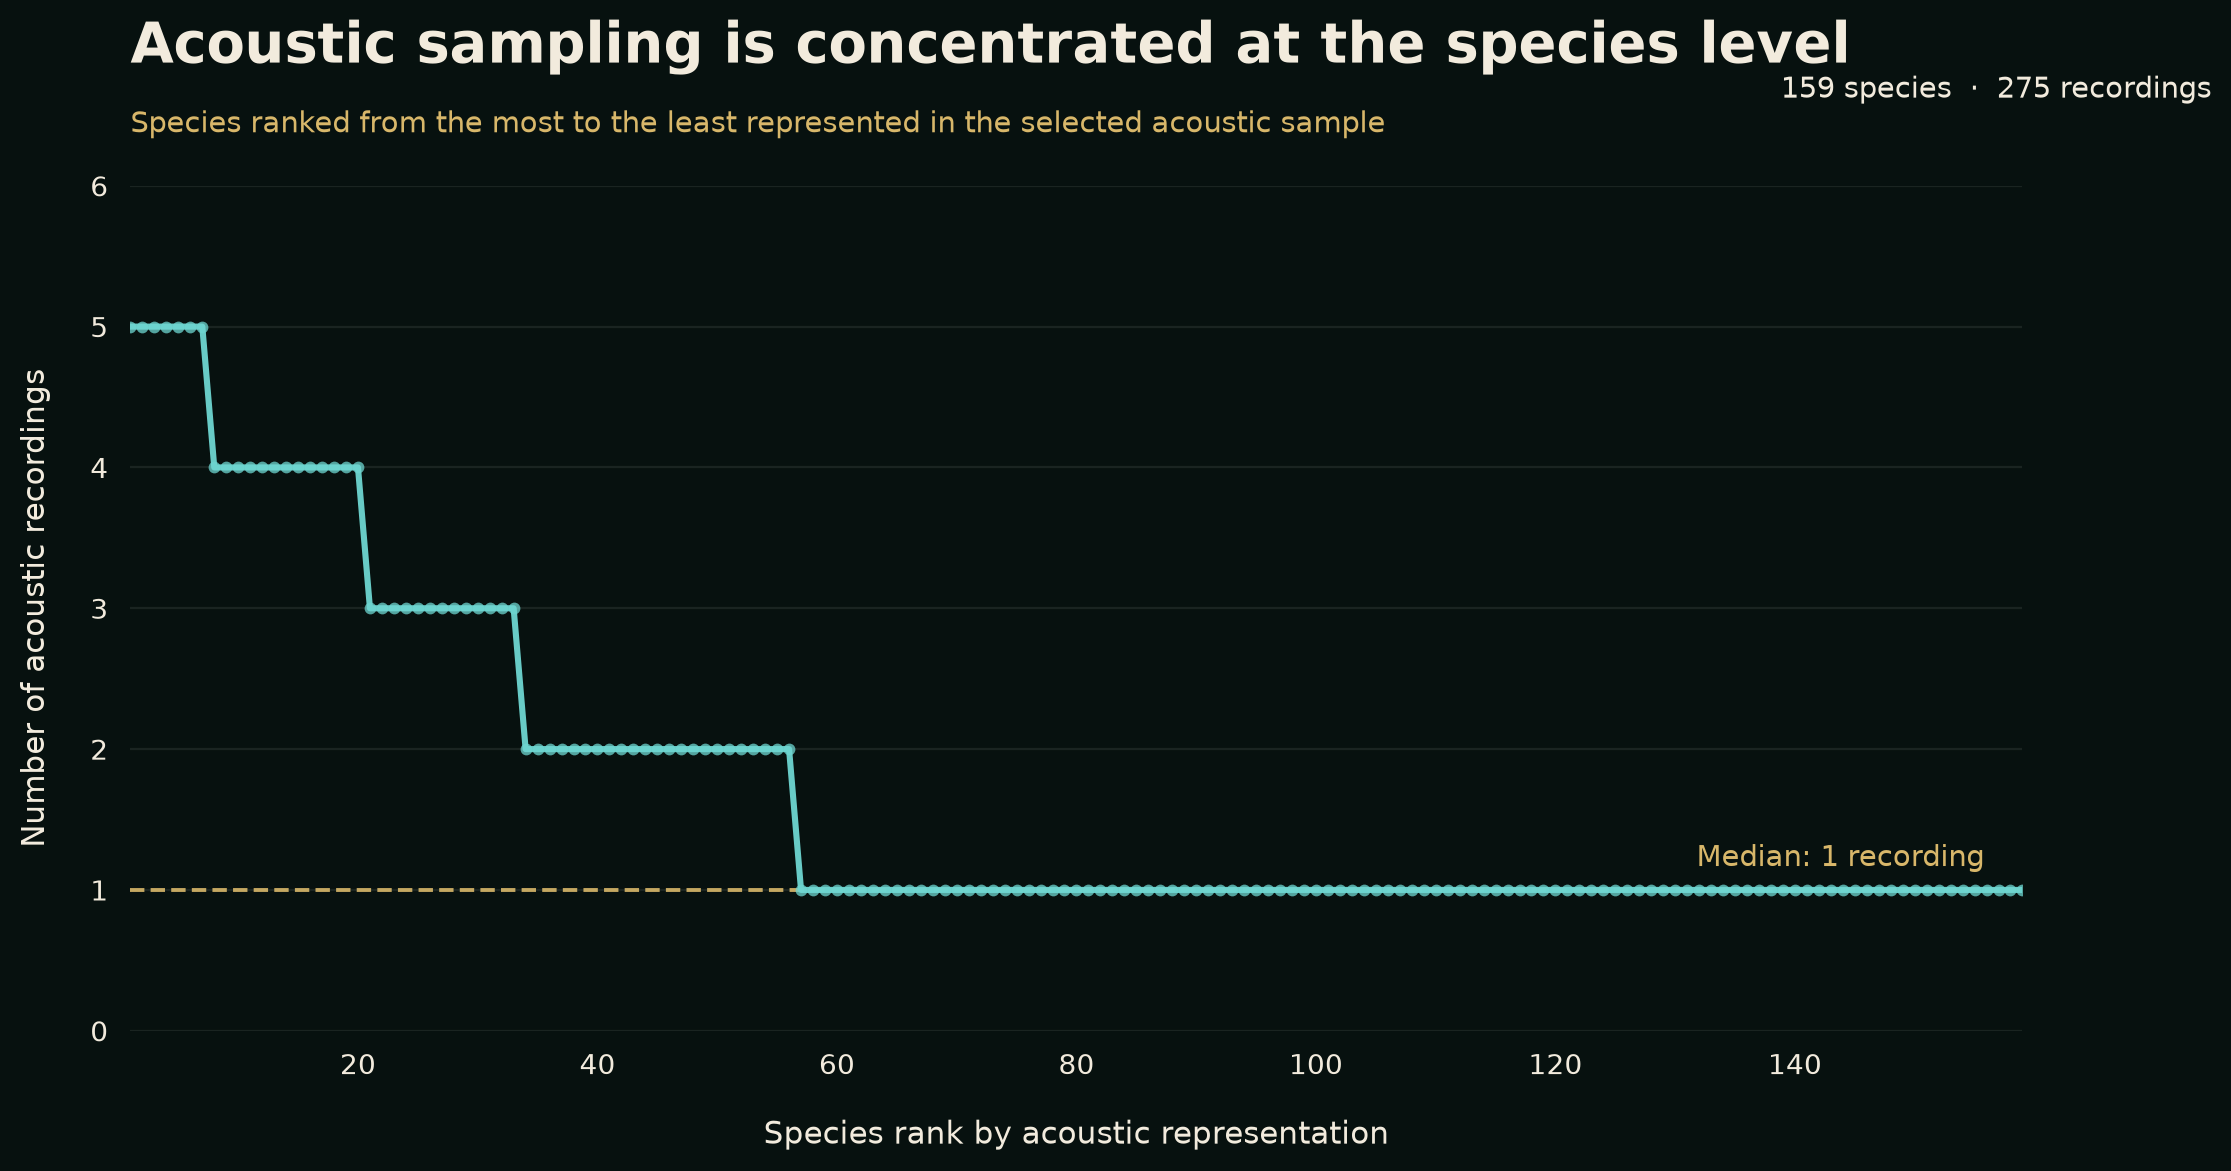

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\04_species_representation.png


In [21]:
# ============================================================
# 19. Figure 04 — Species representation across acoustic sample
# ============================================================

# ------------------------------------------------------------
# Build species-level representation table
# ------------------------------------------------------------

species_representation = (
    features_eda
    .groupby(
        ["species_id", "common_name"],
        dropna=False
    )
    .agg(
        recordings=("recording_id", "nunique"),
        states=("state", "nunique")
    )
    .reset_index()
)

# Rank species by number of acoustic recordings
species_representation = (
    species_representation
    .sort_values(
        ["recordings", "common_name"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

species_representation["rank"] = (
    np.arange(len(species_representation)) + 1
)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

median_recordings = (
    species_representation["recordings"].median()
)

mean_recordings = (
    species_representation["recordings"].mean()
)

max_recordings = (
    species_representation["recordings"].max()
)

print("SPECIES REPRESENTATION SUMMARY")
print("=" * 60)

print("Species:", len(species_representation))
print("Total acoustic recordings:",
      int(species_representation["recordings"].sum()))
print("Median recordings/species:",
      median_recordings)
print("Mean recordings/species:",
      round(mean_recordings, 2))
print("Maximum recordings for one species:",
      int(max_recordings))

print("\nRecording-count distribution:")
print(
    species_representation["recordings"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

ax.set_facecolor(
    EDA_STYLE["background"]
)

# ------------------------------------------------------------
# Main representation curve
# ------------------------------------------------------------

ax.plot(
    species_representation["rank"],
    species_representation["recordings"],
    color=EDA_STYLE["cyan"],
    linewidth=2.2,
    alpha=0.95,
    zorder=3
)

ax.scatter(
    species_representation["rank"],
    species_representation["recordings"],
    color=EDA_STYLE["cyan"],
    s=18,
    alpha=0.75,
    linewidth=0,
    zorder=4
)

# ------------------------------------------------------------
# Median reference
# ------------------------------------------------------------

ax.axhline(
    median_recordings,
    color=EDA_STYLE["gold"],
    linewidth=1.4,
    linestyle="--",
    alpha=0.9,
    zorder=2
)

ax.text(
    len(species_representation) * 0.98,
    median_recordings + 0.12,
    f"Median: {median_recordings:.0f} recording"
    + ("s" if median_recordings != 1 else ""),
    ha="right",
    va="bottom",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(
    axis="y",
    color=EDA_STYLE["grid"],
    linewidth=0.8,
    alpha=0.55
)

ax.set_axisbelow(True)

ax.tick_params(
    colors=EDA_STYLE["foreground"],
    labelsize=10,
    length=0,
    pad=8
)

ax.set_xlabel(
    "Species rank by acoustic representation",
    color=EDA_STYLE["foreground"],
    fontsize=11,
    labelpad=14
)

ax.set_ylabel(
    "Number of acoustic recordings",
    color=EDA_STYLE["foreground"],
    fontsize=11,
    labelpad=14
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0,
    1.13,
    "Acoustic sampling is concentrated at the species level",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=20,
    fontweight="bold"
)

ax.text(
    0,
    1.055,
    "Species ranked from the most to the least represented in the selected acoustic sample",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

# Compact dataset summary
ax.text(
    1.100,
    1.096,
    f"{len(species_representation)} species  ·  "
    f"{int(species_representation['recordings'].sum())} recordings",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=10.5
)
# ------------------------------------------------------------
# Limits
# ------------------------------------------------------------

ax.set_xlim(
    1,
    len(species_representation)
)

ax.set_ylim(
    0,
    max_recordings + 1
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.80,
    bottom=0.15
)

figure_path = (
    EDA_FIGURES_DIR /
    "04_species_representation.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** The acoustic sample contains 159 species represented by 275 recordings, with the median species contributing one recording and the most represented species contributing five. The long tail of single-recording species highlights an important sampling characteristic that should be considered when interpreting species-level patterns and subsequent model evaluation.

In [22]:
# ============================================================
# 20. Recording duration audit
# ============================================================

duration_summary = (
    features_eda[
        [
            "recording_id",
            "state",
            "n_windows",
            "single_window"
        ]
    ]
    .merge(
        master_metadata[
            [
                "recording_id",
                "duration_seconds"
            ]
        ],
        on="recording_id",
        how="left",
        validate="one_to_one"
    )
)

# ------------------------------------------------------------
# Validate duration provenance
# ------------------------------------------------------------

print("RECORDING DURATION SUMMARY")
print("=" * 60)

print("Rows:", len(duration_summary))
print(
    "Missing durations:",
    int(duration_summary["duration_seconds"].isna().sum())
)

assert len(duration_summary) == 275
assert duration_summary["duration_seconds"].notna().all()

# ------------------------------------------------------------
# Overall distribution
# ------------------------------------------------------------

print("\nOverall duration statistics:")
print(
    duration_summary["duration_seconds"]
    .describe()
    .round(2)
)

print("\nDuration < 10 seconds:")
print(
    int(
        (duration_summary["duration_seconds"] < 10).sum()
    )
)

print("\nDuration >= 10 seconds:")
print(
    int(
        (duration_summary["duration_seconds"] >= 10).sum()
    )
)

# ------------------------------------------------------------
# Duration by state
# ------------------------------------------------------------

print("\nDuration by state:")
print(
    duration_summary
    .groupby("state")["duration_seconds"]
    .describe()
    .round(2)
)

RECORDING DURATION SUMMARY
Rows: 275
Missing durations: 0

Overall duration statistics:
count    275.00
mean      46.04
std       64.86
min        0.70
25%       12.86
50%       23.97
75%       54.11
max      646.99
Name: duration_seconds, dtype: float64

Duration < 10 seconds:
53

Duration >= 10 seconds:
222

Duration by state:
       count   mean    std   min    25%    50%    75%     max
state                                                        
AZ      75.0  63.94  96.61  1.86  15.41  31.22  75.22  646.99
CA     100.0  42.60  50.61  0.70  15.41  24.65  49.69  300.00
TX     100.0  36.06  41.83  0.74  10.96  19.98  44.09  216.17


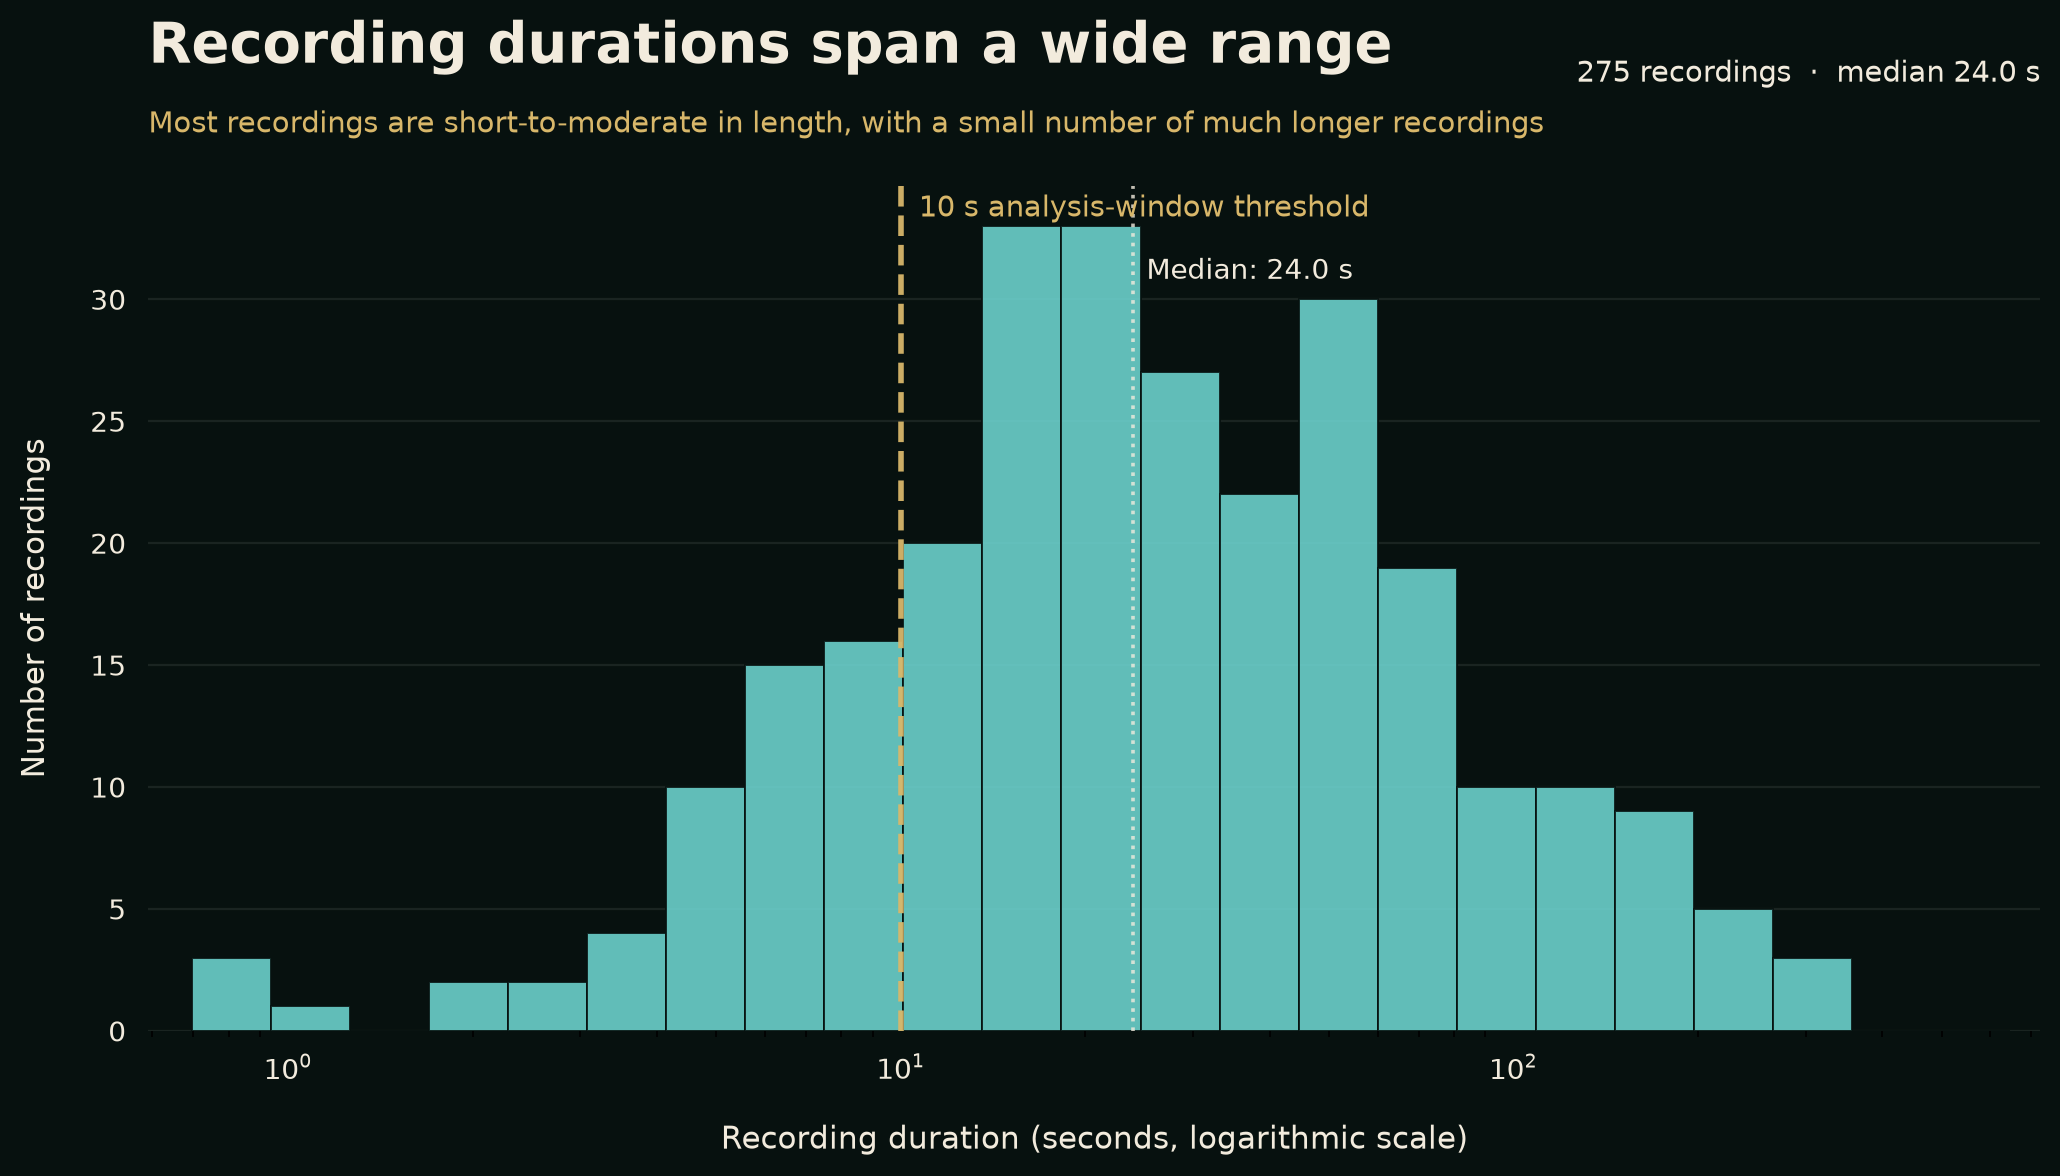

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\05_duration.png


In [23]:
# ============================================================
# 21. Figure 05 — Recording duration distribution
# ============================================================

durations = duration_summary["duration_seconds"].dropna()

# ------------------------------------------------------------
# Log-spaced bins
# ------------------------------------------------------------

log_bins = np.logspace(
    np.log10(durations.min()),
    np.log10(durations.max()),
    24
)

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

ax.set_facecolor(
    EDA_STYLE["background"]
)

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

ax.hist(
    durations,
    bins=log_bins,
    color=EDA_STYLE["cyan"],
    alpha=0.88,
    edgecolor=EDA_STYLE["background"],
    linewidth=0.7
)

# ------------------------------------------------------------
# 10-second analysis threshold
# ------------------------------------------------------------

ax.axvline(
    10,
    color=EDA_STYLE["gold"],
    linewidth=2,
    linestyle="--",
    alpha=0.95
)

# ------------------------------------------------------------
# Median
# ------------------------------------------------------------

median_duration = durations.median()

ax.axvline(
    median_duration,
    color=EDA_STYLE["foreground"],
    linewidth=1.3,
    linestyle=":",
    alpha=0.8
)

# ------------------------------------------------------------
# Annotations
# ------------------------------------------------------------

y_max = ax.get_ylim()[1]

ax.text(
    10.7,
    y_max * 0.99,
    "10 s analysis-window threshold",
    color=EDA_STYLE["gold"],
    fontsize=10.5,
    va="top"
)

ax.text(
    median_duration * 1.05,
    y_max * 0.89,
    f"Median: {median_duration:.1f} s",
    color=EDA_STYLE["foreground"],
    fontsize=10
)

# ------------------------------------------------------------
# Logarithmic x-axis
# ------------------------------------------------------------

ax.set_xscale("log")

ax.set_xlim(
    durations.min() * 0.85,
    durations.max() * 1.12
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(
    axis="y",
    color=EDA_STYLE["grid"],
    linewidth=0.8,
    alpha=0.55
)

ax.set_axisbelow(True)

ax.tick_params(
    colors=EDA_STYLE["foreground"],
    labelsize=10,
    length=0,
    pad=8
)

ax.set_xlabel(
    "Recording duration (seconds, logarithmic scale)",
    color=EDA_STYLE["foreground"],
    fontsize=11,
    labelpad=14
)

ax.set_ylabel(
    "Number of recordings",
    color=EDA_STYLE["foreground"],
    fontsize=11,
    labelpad=14
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0,
    1.13,
    "Recording durations span a wide range",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=20,
    fontweight="bold"
)

ax.text(
    0,
    1.055,
    "Most recordings are short-to-moderate in length, with a small number of much longer recordings",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

ax.text(
    1,
    1.115,
    "275 recordings  ·  median 24.0 s",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.80,
    bottom=0.15
)

figure_path = (
    EDA_FIGURES_DIR /
    "05_duration.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** Recording durations are strongly right-skewed, with a median of 24.0 seconds compared with a mean of 46.0 seconds and a maximum of 647.0 seconds. Fifty-three recordings are shorter than the 10-second analysis window and therefore contribute their full available duration, while longer recordings are analyzed using complete 10-second windows.

In [24]:
# ============================================================
# 22. Recording quality audit
# ============================================================

quality_summary = (
    features_eda[
        [
            "recording_id",
            "state",
            "flag_any",
            "flag_short_duration",
            "flag_low_amplitude",
            "flag_clipping",
            "flag_low_quality"
        ]
    ]
    .merge(
        master_metadata[
            [
                "recording_id",
                "quality"
            ]
        ],
        on="recording_id",
        how="left",
        validate="one_to_one"
    )
)

# ------------------------------------------------------------
# Validate provenance
# ------------------------------------------------------------

print("RECORDING QUALITY SUMMARY")
print("=" * 60)

print("Rows:", len(quality_summary))
print(
    "Missing quality values:",
    int(quality_summary["quality"].isna().sum())
)

assert len(quality_summary) == 275

# ------------------------------------------------------------
# Quality categories
# ------------------------------------------------------------

print("\nQuality categories:")
print(
    quality_summary["quality"]
    .value_counts(dropna=False)
    .sort_index()
)

# ------------------------------------------------------------
# Overall audit flags
# ------------------------------------------------------------

print("\nAny audit flag:")
print(
    quality_summary["flag_any"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# Individual audit flags
# ------------------------------------------------------------

print("\nIndividual audit flags:")

for col in [
    "flag_short_duration",
    "flag_low_amplitude",
    "flag_clipping",
    "flag_low_quality"
]:
    print(
        f"{col}: "
        f"{int(quality_summary[col].sum())}"
    )

# ------------------------------------------------------------
# Quality by state
# ------------------------------------------------------------

print("\nQuality by state:")
print(
    pd.crosstab(
        quality_summary["state"],
        quality_summary["quality"]
    )
)

RECORDING QUALITY SUMMARY
Rows: 275
Missing quality values: 0

Quality categories:
quality
A     86
B    189
Name: count, dtype: int64

Any audit flag:
flag_any
False    208
True      67
Name: count, dtype: int64

Individual audit flags:
flag_short_duration: 8
flag_low_amplitude: 53
flag_clipping: 8
flag_low_quality: 0

Quality by state:
quality   A   B
state          
AZ       21  54
CA       35  65
TX       30  70


QUALITY COMPOSITION BY STATE


quality,A,B
state,,
AZ,21,54
CA,35,65
TX,30,70



Percentage composition:


quality,A,B
state,,
AZ,28.0,72.0
CA,35.0,65.0
TX,30.0,70.0


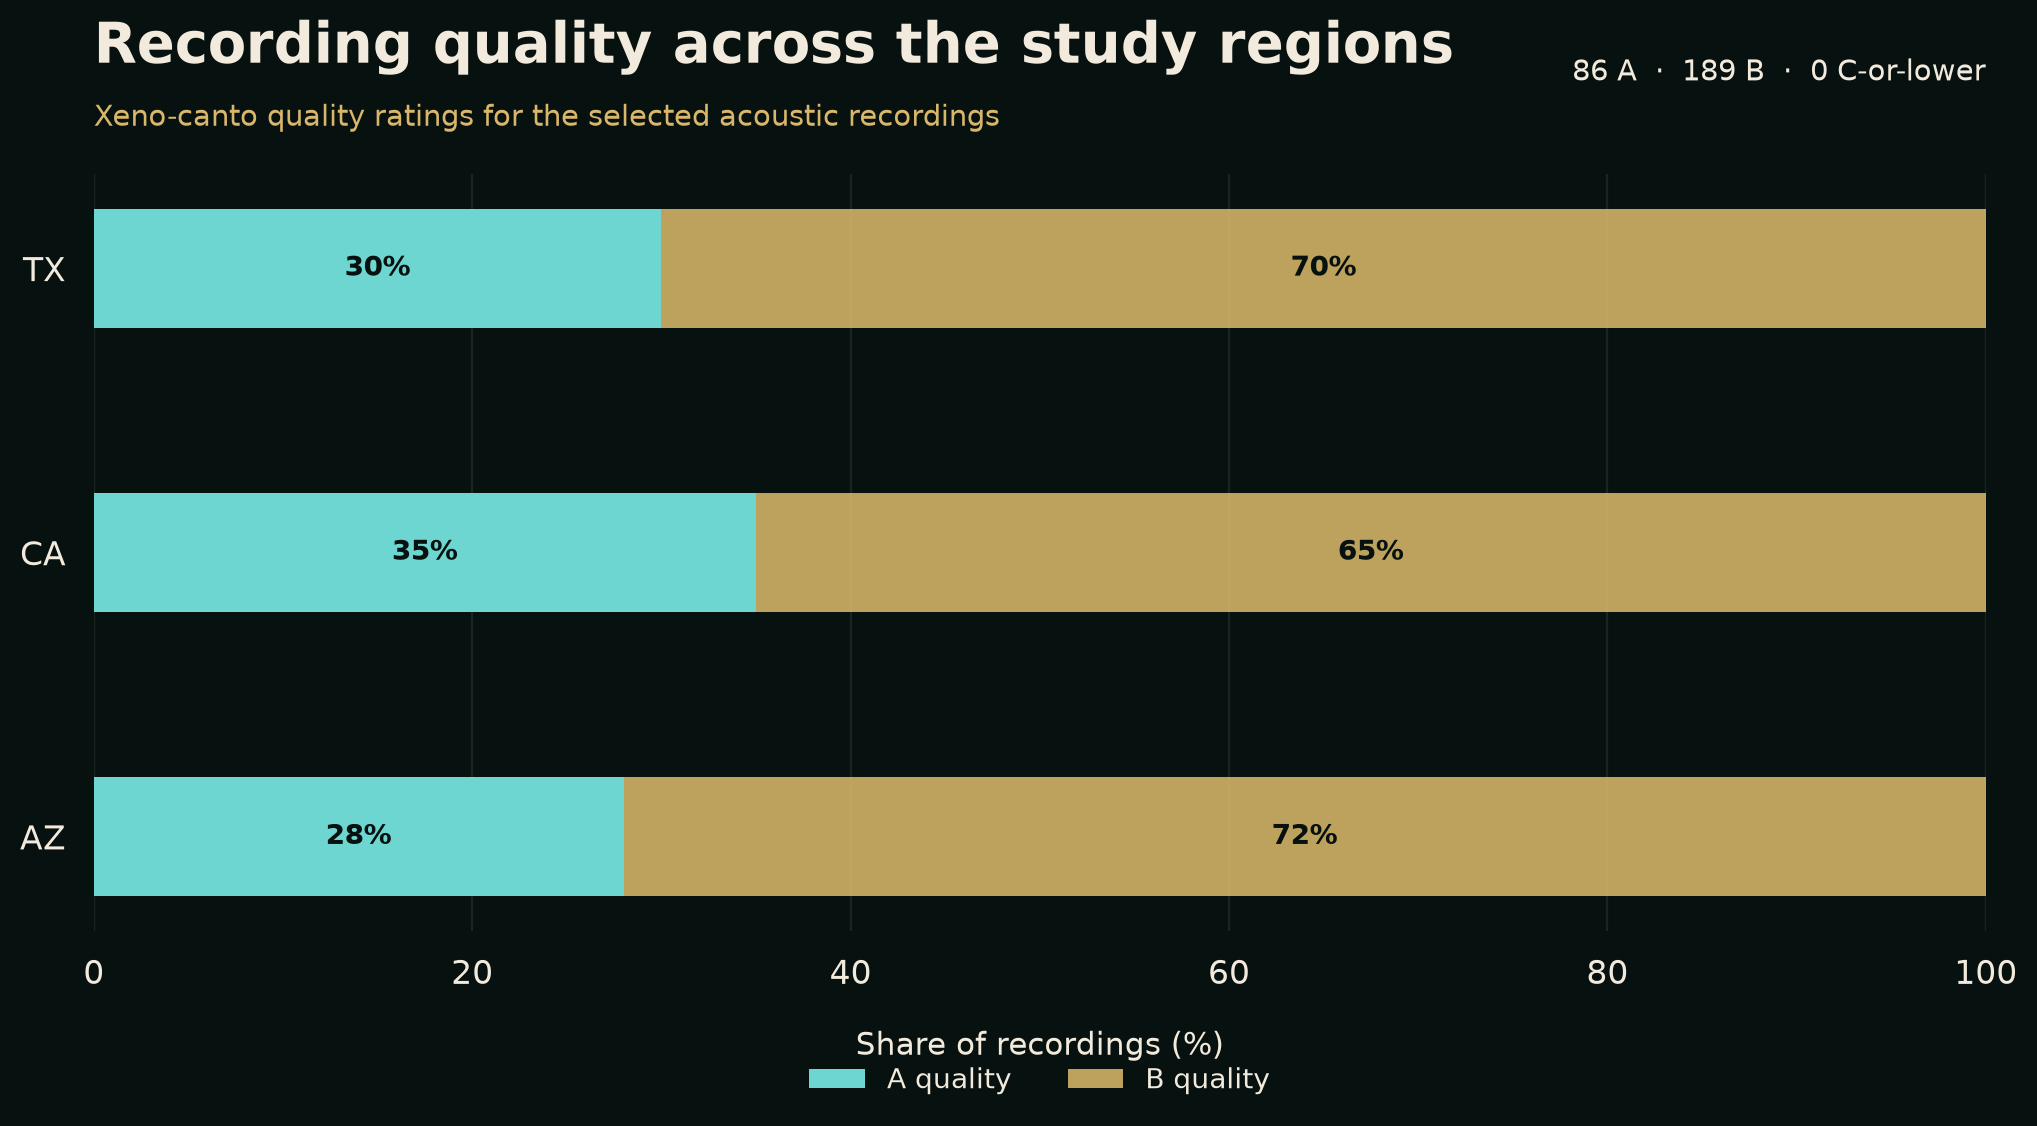

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\06_quality.png


In [25]:
# ============================================================
# 23. Figure 06 — Recording quality by state
# ============================================================

# ------------------------------------------------------------
# Quality proportions by state
# ------------------------------------------------------------

quality_counts = (
    pd.crosstab(
        quality_summary["state"],
        quality_summary["quality"]
    )
    .reindex(
        ["AZ", "CA", "TX"]
    )
    .fillna(0)
)

quality_pct = (
    quality_counts
    .div(quality_counts.sum(axis=1), axis=0)
    * 100
)

print("QUALITY COMPOSITION BY STATE")
print("=" * 60)

display(quality_counts)

print("\nPercentage composition:")
display(
    quality_pct.round(1)
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6.2),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

ax.set_facecolor(
    EDA_STYLE["background"]
)

# ------------------------------------------------------------
# Stacked bars
# ------------------------------------------------------------

states = quality_pct.index

a_values = quality_pct["A"]
b_values = quality_pct["B"]

ax.barh(
    states,
    a_values,
    height=0.42,
    color=EDA_STYLE["cyan"],
    label="A quality"
)

ax.barh(
    states,
    b_values,
    left=a_values,
    height=0.42,
    color=EDA_STYLE["gold"],
    alpha=0.88,
    label="B quality"
)

# ------------------------------------------------------------
# Percentage labels
# ------------------------------------------------------------

for i, state in enumerate(states):

    a_pct = a_values.loc[state]
    b_pct = b_values.loc[state]

    if a_pct >= 8:
        ax.text(
            a_pct / 2,
            i,
            f"{a_pct:.0f}%",
            ha="center",
            va="center",
            color=EDA_STYLE["background"],
            fontsize=10,
            fontweight="bold"
        )

    if b_pct >= 8:
        ax.text(
            a_pct + b_pct / 2,
            i,
            f"{b_pct:.0f}%",
            ha="center",
            va="center",
            color=EDA_STYLE["background"],
            fontsize=10,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(
    axis="x",
    color=EDA_STYLE["grid"],
    linewidth=0.8,
    alpha=0.55
)

ax.set_axisbelow(True)

ax.tick_params(
    colors=EDA_STYLE["foreground"],
    labelsize=12,
    length=0,
    pad=10
)

ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.set_xlabel(
    "Share of recordings (%)",
    color=EDA_STYLE["foreground"],
    fontsize=11,
    labelpad=14
)

ax.set_ylabel("")

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0,
    1.13,
    "Recording quality across the study regions",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=20,
    fontweight="bold"
)

ax.text(
    0,
    1.055,
    "Xeno-canto quality ratings for the selected acoustic recordings",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

ax.text(
    1,
    1.115,
    "86 A  ·  189 B  ·  0 C-or-lower",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=False,
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(EDA_STYLE["foreground"])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.80,
    bottom=0.19
)

figure_path = (
    EDA_FIGURES_DIR /
    "06_quality.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** The selected acoustic sample contains 86 A-quality and 189 B-quality Xeno-canto recordings, with no recordings classified below B quality. Quality composition is broadly similar across Arizona, California, and Texas, while separate acoustic audits identify 67 recordings with at least one screening flag that does not necessarily indicate a low Xeno-canto quality rating.

In [26]:
# ============================================================
# 24. Seasonal sampling audit
# ============================================================

season_summary = (
    features_eda[
        [
            "recording_id",
            "state"
        ]
    ]
    .merge(
        master_metadata[
            [
                "recording_id",
                "season"
            ]
        ],
        on="recording_id",
        how="left",
        validate="one_to_one"
    )
)

print("SEASONAL SAMPLING SUMMARY")
print("=" * 60)

print("Rows:", len(season_summary))
print(
    "Missing season:",
    int(season_summary["season"].isna().sum())
)

print("\nOverall season counts:")
print(
    season_summary["season"]
    .value_counts(dropna=False)
)

print("\nSeason by state:")
print(
    pd.crosstab(
        season_summary["state"],
        season_summary["season"]
    )
)

SEASONAL SAMPLING SUMMARY
Rows: 275
Missing season: 5

Overall season counts:
season
Spring    107
Summer     73
Winter     71
Fall       19
NaN         5
Name: count, dtype: int64

Season by state:
season  Fall  Spring  Summer  Winter
state                               
AZ         8      26      23      17
CA         4      32      30      32
TX         7      49      20      22


SEASONAL RECORDING COUNTS


season,Spring,Summer,Fall,Winter,Unknown
state,,,,,
AZ,26,23,8,17,1
CA,32,30,4,32,2
TX,49,20,7,22,2


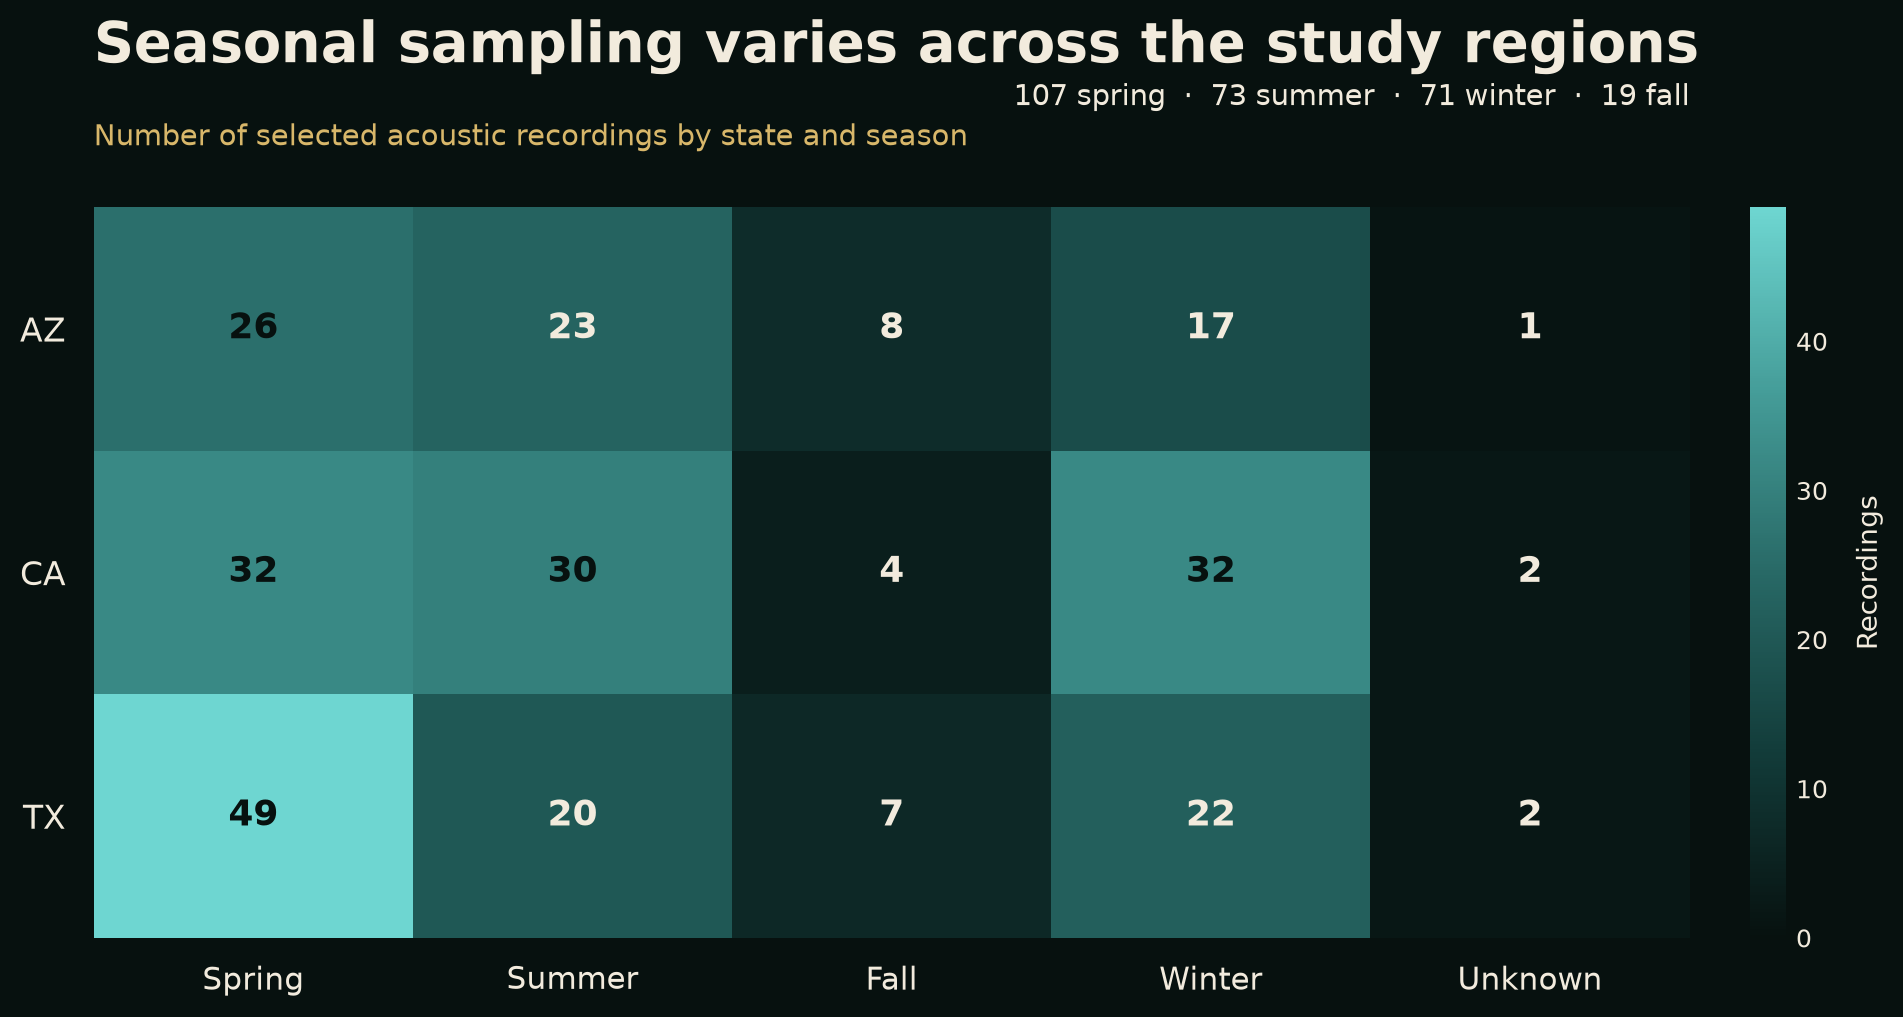

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\07_seasonality.png


In [27]:
# ============================================================
# 25. Figure 07 — Seasonal sampling heatmap
# ============================================================

from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Build season table
# ------------------------------------------------------------

season_order = [
    "Spring",
    "Summer",
    "Fall",
    "Winter",
    "Unknown"
]

season_plot = season_summary.copy()

season_plot["season"] = (
    season_plot["season"]
    .fillna("Unknown")
)

season_counts = pd.crosstab(
    season_plot["state"],
    season_plot["season"]
)

season_counts = (
    season_counts
    .reindex(
        index=["AZ", "CA", "TX"],
        columns=season_order,
        fill_value=0
    )
)

print("SEASONAL RECORDING COUNTS")
print("=" * 60)

display(season_counts)

# ------------------------------------------------------------
# Custom website-native cyan colormap
# ------------------------------------------------------------

season_cmap = LinearSegmentedColormap.from_list(
    "forest_to_cyan",
    [
        EDA_STYLE["background"],
        "#123b39",
        "#286966",
        "#459d99",
        EDA_STYLE["cyan"]
    ]
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5.8),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

ax.set_facecolor(
    EDA_STYLE["background"]
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

im = ax.imshow(
    season_counts.values,
    aspect="auto",
    cmap=season_cmap,
    vmin=0,
    vmax=season_counts.values.max()
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(len(season_order))
)

ax.set_xticklabels(
    season_order,
    color=EDA_STYLE["foreground"],
    fontsize=11
)

ax.set_yticks(
    np.arange(len(season_counts.index))
)

ax.set_yticklabels(
    season_counts.index,
    color=EDA_STYLE["foreground"],
    fontsize=12
)

ax.tick_params(
    length=0,
    pad=10
)

# ------------------------------------------------------------
# Cell values
# ------------------------------------------------------------

max_value = season_counts.values.max()

for i in range(season_counts.shape[0]):
    for j in range(season_counts.shape[1]):

        value = season_counts.iloc[i, j]

        # Dark text on bright cells, cream on dark cells
        text_color = (
            EDA_STYLE["background"]
            if value >= max_value * 0.48
            else EDA_STYLE["foreground"]
        )

        ax.text(
            j,
            i,
            str(int(value)),
            ha="center",
            va="center",
            color=text_color,
            fontsize=13,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Remove spines
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0,
    1.18,
    "Seasonal sampling varies across the study regions",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=20,
    fontweight="bold"
)

ax.text(
    0,
    1.075,
    "Number of selected acoustic recordings by state and season",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

ax.text(
    1,
    1.13,
    "107 spring  ·  73 summer  ·  71 winter  ·  19 fall",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    color=EDA_STYLE["foreground"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.035
)

cbar.outline.set_visible(False)

cbar.ax.tick_params(
    colors=EDA_STYLE["foreground"],
    length=0,
    labelsize=9
)

cbar.set_label(
    "Recordings",
    color=EDA_STYLE["foreground"],
    fontsize=10,
    labelpad=10
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.88,
    top=0.78,
    bottom=0.15
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = (
    EDA_FIGURES_DIR /
    "07_seasonality.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** The selected acoustic recordings are distributed unevenly across seasons and regions, with spring contributing the largest overall share and fall the smallest. Five recordings have insufficient temporal metadata to assign a season and are retained as an explicit unknown category rather than being removed.

In [28]:
# ============================================================
# 26. Time-of-day sampling audit
# ============================================================

time_summary = (
    features_eda[
        [
            "recording_id",
            "state"
        ]
    ]
    .merge(
        master_metadata[
            [
                "recording_id",
                "time",
                "hour",
                "minute",
                "has_time"
            ]
        ],
        on="recording_id",
        how="left",
        validate="one_to_one"
    )
)

print("TIME-OF-DAY SAMPLING SUMMARY")
print("=" * 60)

print("Rows:", len(time_summary))

print(
    "Missing time:",
    int(time_summary["time"].isna().sum())
)

print(
    "Missing hour:",
    int(time_summary["hour"].isna().sum())
)

print("\nRecordings by hour:")

hour_counts = (
    time_summary["hour"]
    .value_counts()
    .sort_index()
)

print(hour_counts)

print("\nTime coverage by state:")

state_hour_counts = pd.crosstab(
    time_summary["state"],
    time_summary["hour"]
)

display(state_hour_counts)

TIME-OF-DAY SAMPLING SUMMARY
Rows: 275
Missing time: 5
Missing hour: 5

Recordings by hour:
hour
0.0      1
3.0      2
4.0      3
5.0     12
6.0     15
7.0     47
8.0     25
9.0     24
10.0    22
11.0    11
12.0    15
13.0    12
14.0    12
15.0    13
16.0     6
17.0    17
18.0     8
19.0     9
20.0     6
21.0     8
22.0     1
23.0     1
Name: count, dtype: int64

Time coverage by state:


hour,0.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
state,,,,,,,,,,,,,,,,,,,,,
AZ,0,1,3,6,5,13,7,5,3,2,...,1,3,1,8,3,3,2,0,0,0
CA,0,1,0,4,5,13,13,12,6,4,...,7,5,3,6,3,2,2,4,0,0
TX,1,0,0,2,5,21,5,7,13,5,...,4,5,2,3,2,4,2,4,1,1


TIME-OF-DAY DISTRIBUTION
Recordings with known time: 270
Recordings without time: 5
Peak recording hour: 7
Peak hour recordings: 47

Hourly counts:
hour
0      1
1      0
2      0
3      2
4      3
5     12
6     15
7     47
8     25
9     24
10    22
11    11
12    15
13    12
14    12
15    13
16     6
17    17
18     8
19     9
20     6
21     8
22     1
23     1
Name: count, dtype: int64


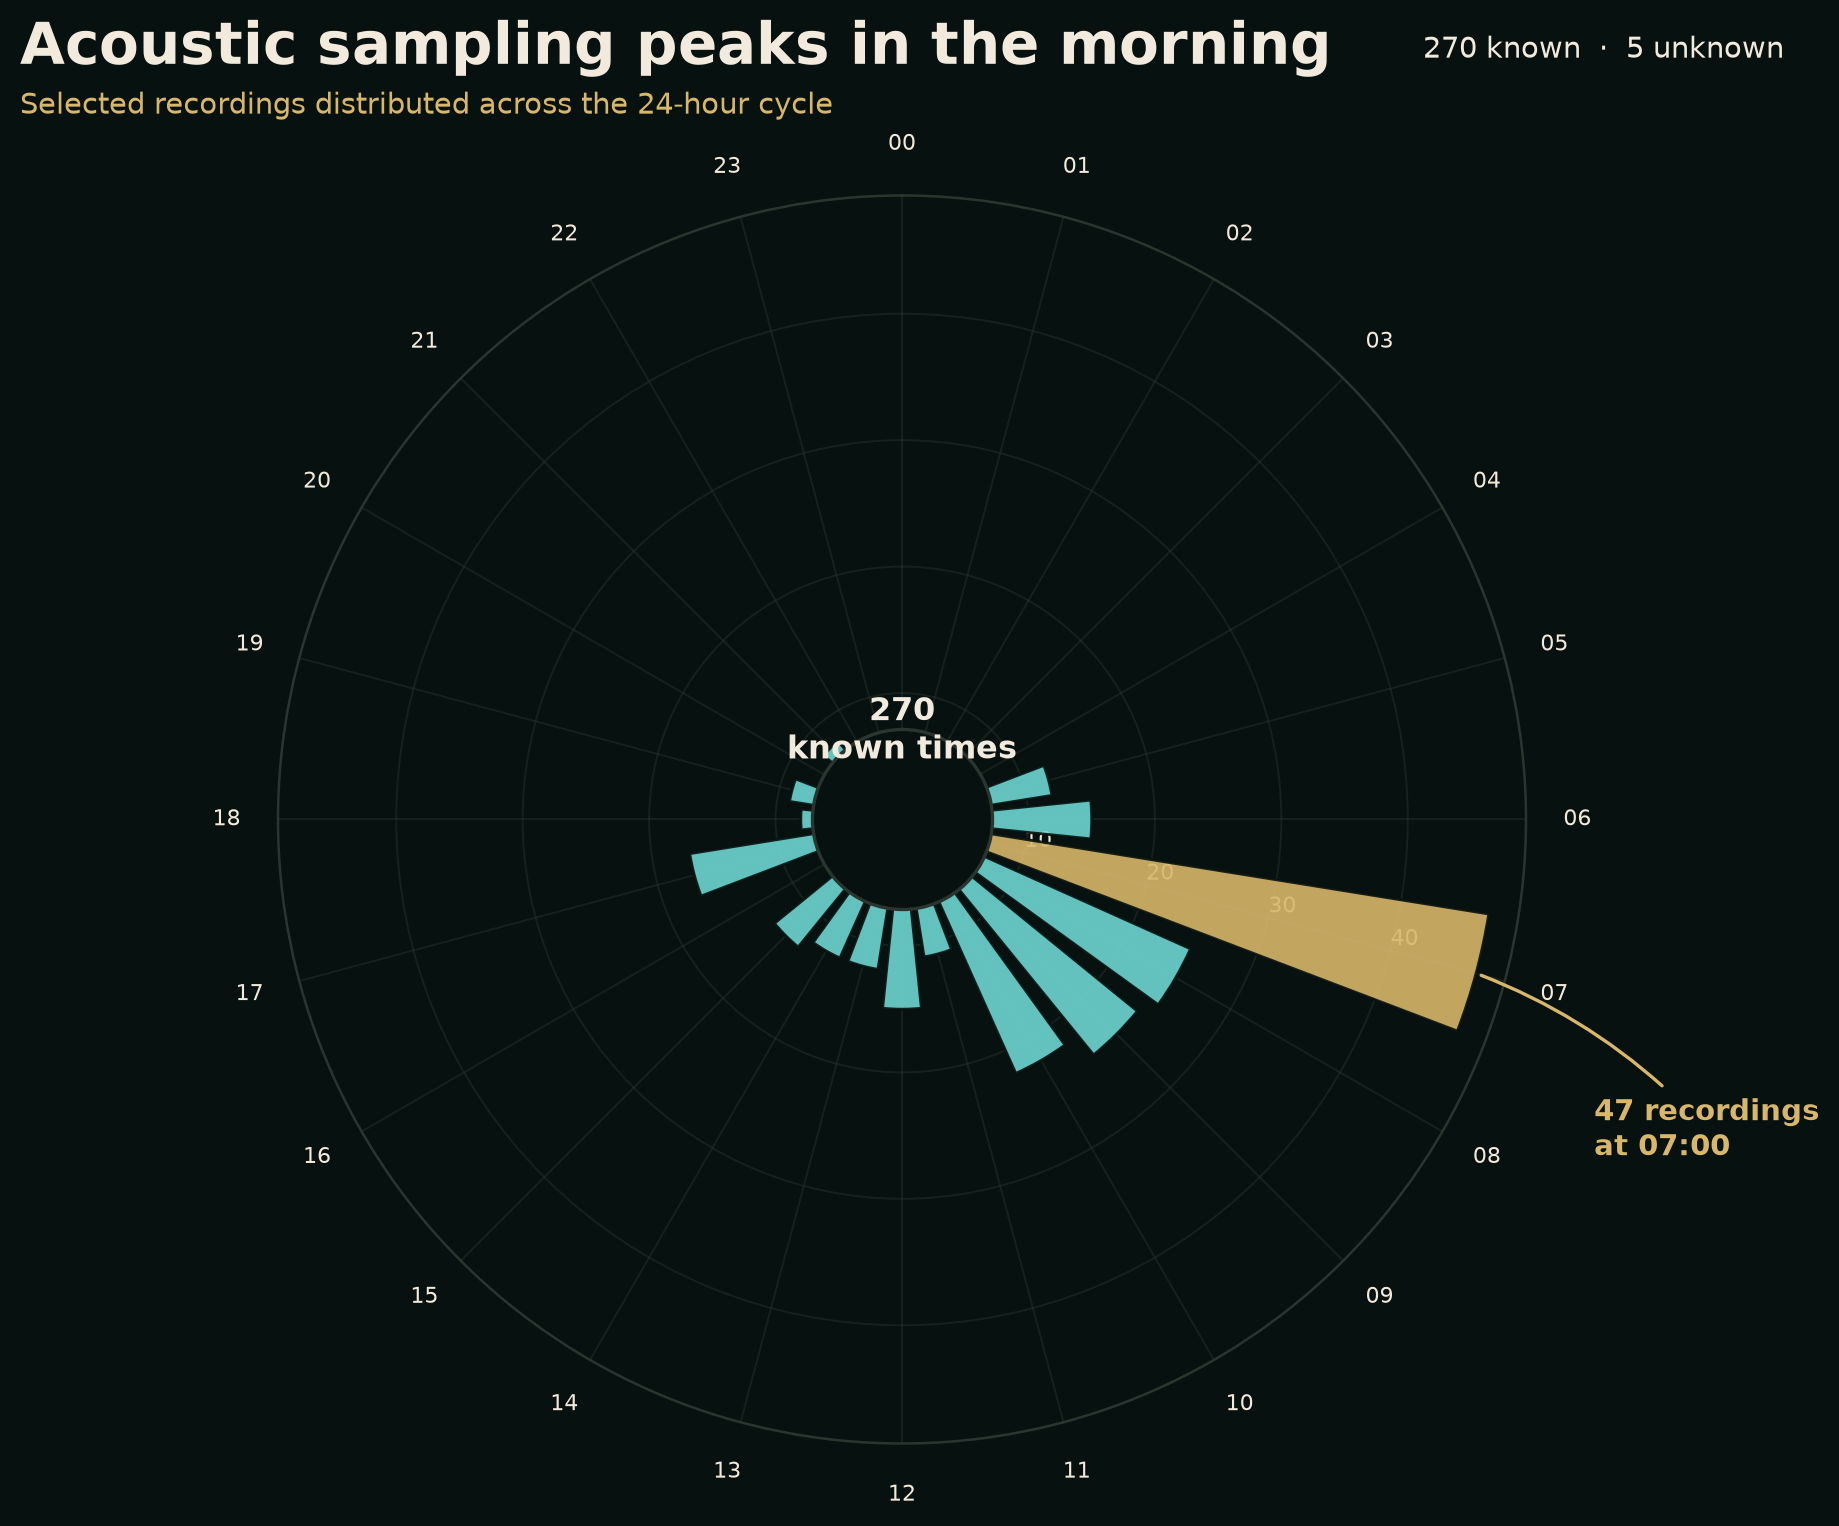

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\08_time_of_day.png


In [29]:
# ============================================================
# 27. Figure 08 — Time-of-day sampling
# ============================================================

# ------------------------------------------------------------
# Prepare hourly counts
# ------------------------------------------------------------

hour_counts = (
    time_summary["hour"]
    .dropna()
    .astype(int)
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

known_time_count = int(hour_counts.sum())
unknown_time_count = int(time_summary["hour"].isna().sum())

peak_hour = int(hour_counts.idxmax())
peak_count = int(hour_counts.max())

print("TIME-OF-DAY DISTRIBUTION")
print("=" * 60)

print("Recordings with known time:", known_time_count)
print("Recordings without time:", unknown_time_count)
print("Peak recording hour:", peak_hour)
print("Peak hour recordings:", peak_count)

print("\nHourly counts:")
print(hour_counts)

# ------------------------------------------------------------
# Polar geometry
# ------------------------------------------------------------

hours = np.arange(24)

theta = 2 * np.pi * hours / 24

bar_width = (
    2 * np.pi / 24 * 0.78
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(10.5, 8),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

ax = fig.add_subplot(
    111,
    projection="polar"
)

ax.set_facecolor(
    EDA_STYLE["background"]
)

# Midnight at top, clockwise
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# ------------------------------------------------------------
# Bars
# ------------------------------------------------------------

bar_colors = [
    EDA_STYLE["gold"]
    if h == peak_hour
    else EDA_STYLE["cyan"]
    for h in hours
]

ax.bar(
    theta,
    hour_counts.values,
    width=bar_width,
    color=bar_colors,
    alpha=0.90,
    edgecolor=EDA_STYLE["background"],
    linewidth=1.0,
    zorder=3
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    color=EDA_STYLE["grid"],
    linewidth=0.7,
    alpha=0.45
)

ax.spines["polar"].set_color(
    EDA_STYLE["grid"]
)

ax.spines["polar"].set_linewidth(0.9)

# ------------------------------------------------------------
# Hour labels
# ------------------------------------------------------------

ax.set_xticks(
    2 * np.pi * np.arange(24) / 24
)

ax.set_xticklabels(
    [
        "00", "01", "02", "03",
        "04", "05", "06", "07",
        "08", "09", "10", "11",
        "12", "13", "14", "15",
        "16", "17", "18", "19",
        "20", "21", "22", "23"
    ],
    color=EDA_STYLE["foreground"],
    fontsize=8
)

ax.tick_params(
    axis="x",
    pad=8
)

# ------------------------------------------------------------
# Radial labels
# ------------------------------------------------------------

ax.tick_params(
    axis="y",
    colors=EDA_STYLE["foreground"],
    labelsize=8
)

ax.set_rlabel_position(105)

# ------------------------------------------------------------
# Center hub
# ------------------------------------------------------------

ax.scatter(
    0,
    0,
    s=4200,
    color=EDA_STYLE["background"],
    edgecolor=EDA_STYLE["grid"],
    linewidth=1.2,
    zorder=5
)

ax.text(
    0,
    7,
    f"{known_time_count}\nknown times",
    ha="center",
    va="center",
    color=EDA_STYLE["foreground"],
    fontsize=11.5,
    fontweight="bold",
    zorder=6
)

# ------------------------------------------------------------
# Peak-hour annotation
# ------------------------------------------------------------

peak_theta = theta[peak_hour]

ax.annotate(
    f"{peak_count} recordings\nat {peak_hour:02d}:00",
    xy=(
        peak_theta,
        peak_count
    ),
    xytext=(
        peak_theta + 0.16,
        peak_count + 13
    ),
    color=EDA_STYLE["gold"],
    fontsize=10.5,
    fontweight="bold",
    ha="left",
    va="center",
    zorder=7,
    arrowprops=dict(
        arrowstyle="-",
        color=EDA_STYLE["gold"],
        linewidth=1.2,
        connectionstyle="arc3,rad=0.12"
    )
)
# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

fig.text(
    0.08,
    0.95,
    "Acoustic sampling peaks in the morning",
    ha="left",
    va="top",
    color=EDA_STYLE["foreground"],
    fontsize=21,
    fontweight="bold"
)

fig.text(
    0.08,
    0.905,
    "Selected recordings distributed across the 24-hour cycle",
    ha="left",
    va="top",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

fig.text(
    0.92,
    0.94,
    f"{known_time_count} known  ·  "
    f"{unknown_time_count} unknown",
    ha="right",
    va="top",
    color=EDA_STYLE["foreground"],
    fontsize=10.5
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.subplots_adjust(
    top=0.84,
    bottom=0.06,
    left=0.04,
    right=0.96
)

figure_path = (
    EDA_FIGURES_DIR /
    "08_time_of_day.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** Recording times are concentrated during daylight and particularly in the morning, with the largest number of selected recordings occurring at 07:00. Five recordings lack sufficient time metadata and are retained as an explicit unknown category rather than being excluded from the analysis.

In [30]:
# ============================================================
# 28A. Inspect acoustic-index column names
# ============================================================

print("COLUMNS CONTAINING ACOUSTIC INDEX TERMS")
print("=" * 60)

index_terms = [
    "aci",
    "adi",
    "ndsi",
    "bio"
]

for term in index_terms:
    matches = [
        col
        for col in features_eda.columns
        if term.lower() in col.lower()
    ]

    print(f"\n{term.upper()}:")
    for col in matches:
        print("  ", col)

COLUMNS CONTAINING ACOUSTIC INDEX TERMS

ACI:
   aci_mean
   aci_std

ADI:
   adi_mean
   adi_std

NDSI:
   ndsi_mean
   ndsi_ratio_ba_mean
   ndsi_std
   ndsi_ratio_ba_std

BIO:
   bioacoustic_index_mean
   biophony_mean
   bioacoustic_index_std
   biophony_std


In [31]:
# ============================================================
# 28B. Acoustic index audit — recording-level means
# ============================================================

acoustic_index_columns = [
    "aci_mean",
    "adi_mean",
    "ndsi_mean",
    "bioacoustic_index_mean"
]

print("ACOUSTIC INDEX SUMMARY")
print("=" * 60)

index_summary = (
    features_eda[acoustic_index_columns]
    .describe()
    .T
)

print("\nOverall distributions:")
display(
    index_summary[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ].round(4)
)

print("\nMissing values:")
print(
    features_eda[
        acoustic_index_columns
    ]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        features_eda[
            acoustic_index_columns
        ]
    )
    .sum()
)

print("\nState-level means:")
display(
    features_eda
    .groupby("state")[acoustic_index_columns]
    .mean()
    .round(4)
)


ACOUSTIC INDEX SUMMARY

Overall distributions:


,count,mean,std,min,25%,50%,75%,max
aci_mean,275.0,443.9523,47.3764,368.3148,407.6612,432.7635,471.9294,670.5210
adi_mean,275.0,1.8428,0.3568,0.4753,1.6354,1.9401,2.1424,2.1972
ndsi_mean,275.0,0.1614,0.6259,-0.9996,-0.2940,0.1979,0.7613,0.9999
bioacoustic_index_mean,275.0,990.7992,735.9337,124.9190,592.7404,862.2843,1157.2979,7573.5336



Missing values:
aci_mean                  0
adi_mean                  0
ndsi_mean                 0
bioacoustic_index_mean    0
dtype: int64

Infinite values:
aci_mean                  0
adi_mean                  0
ndsi_mean                 0
bioacoustic_index_mean    0
dtype: int64

State-level means:


,aci_mean,adi_mean,ndsi_mean,bioacoustic_index_mean
state,,,,
AZ,444.7111,1.8706,0.2816,936.4426
CA,439.4638,1.8041,-0.0874,824.9750
TX,447.8715,1.8606,0.3199,1197.3908


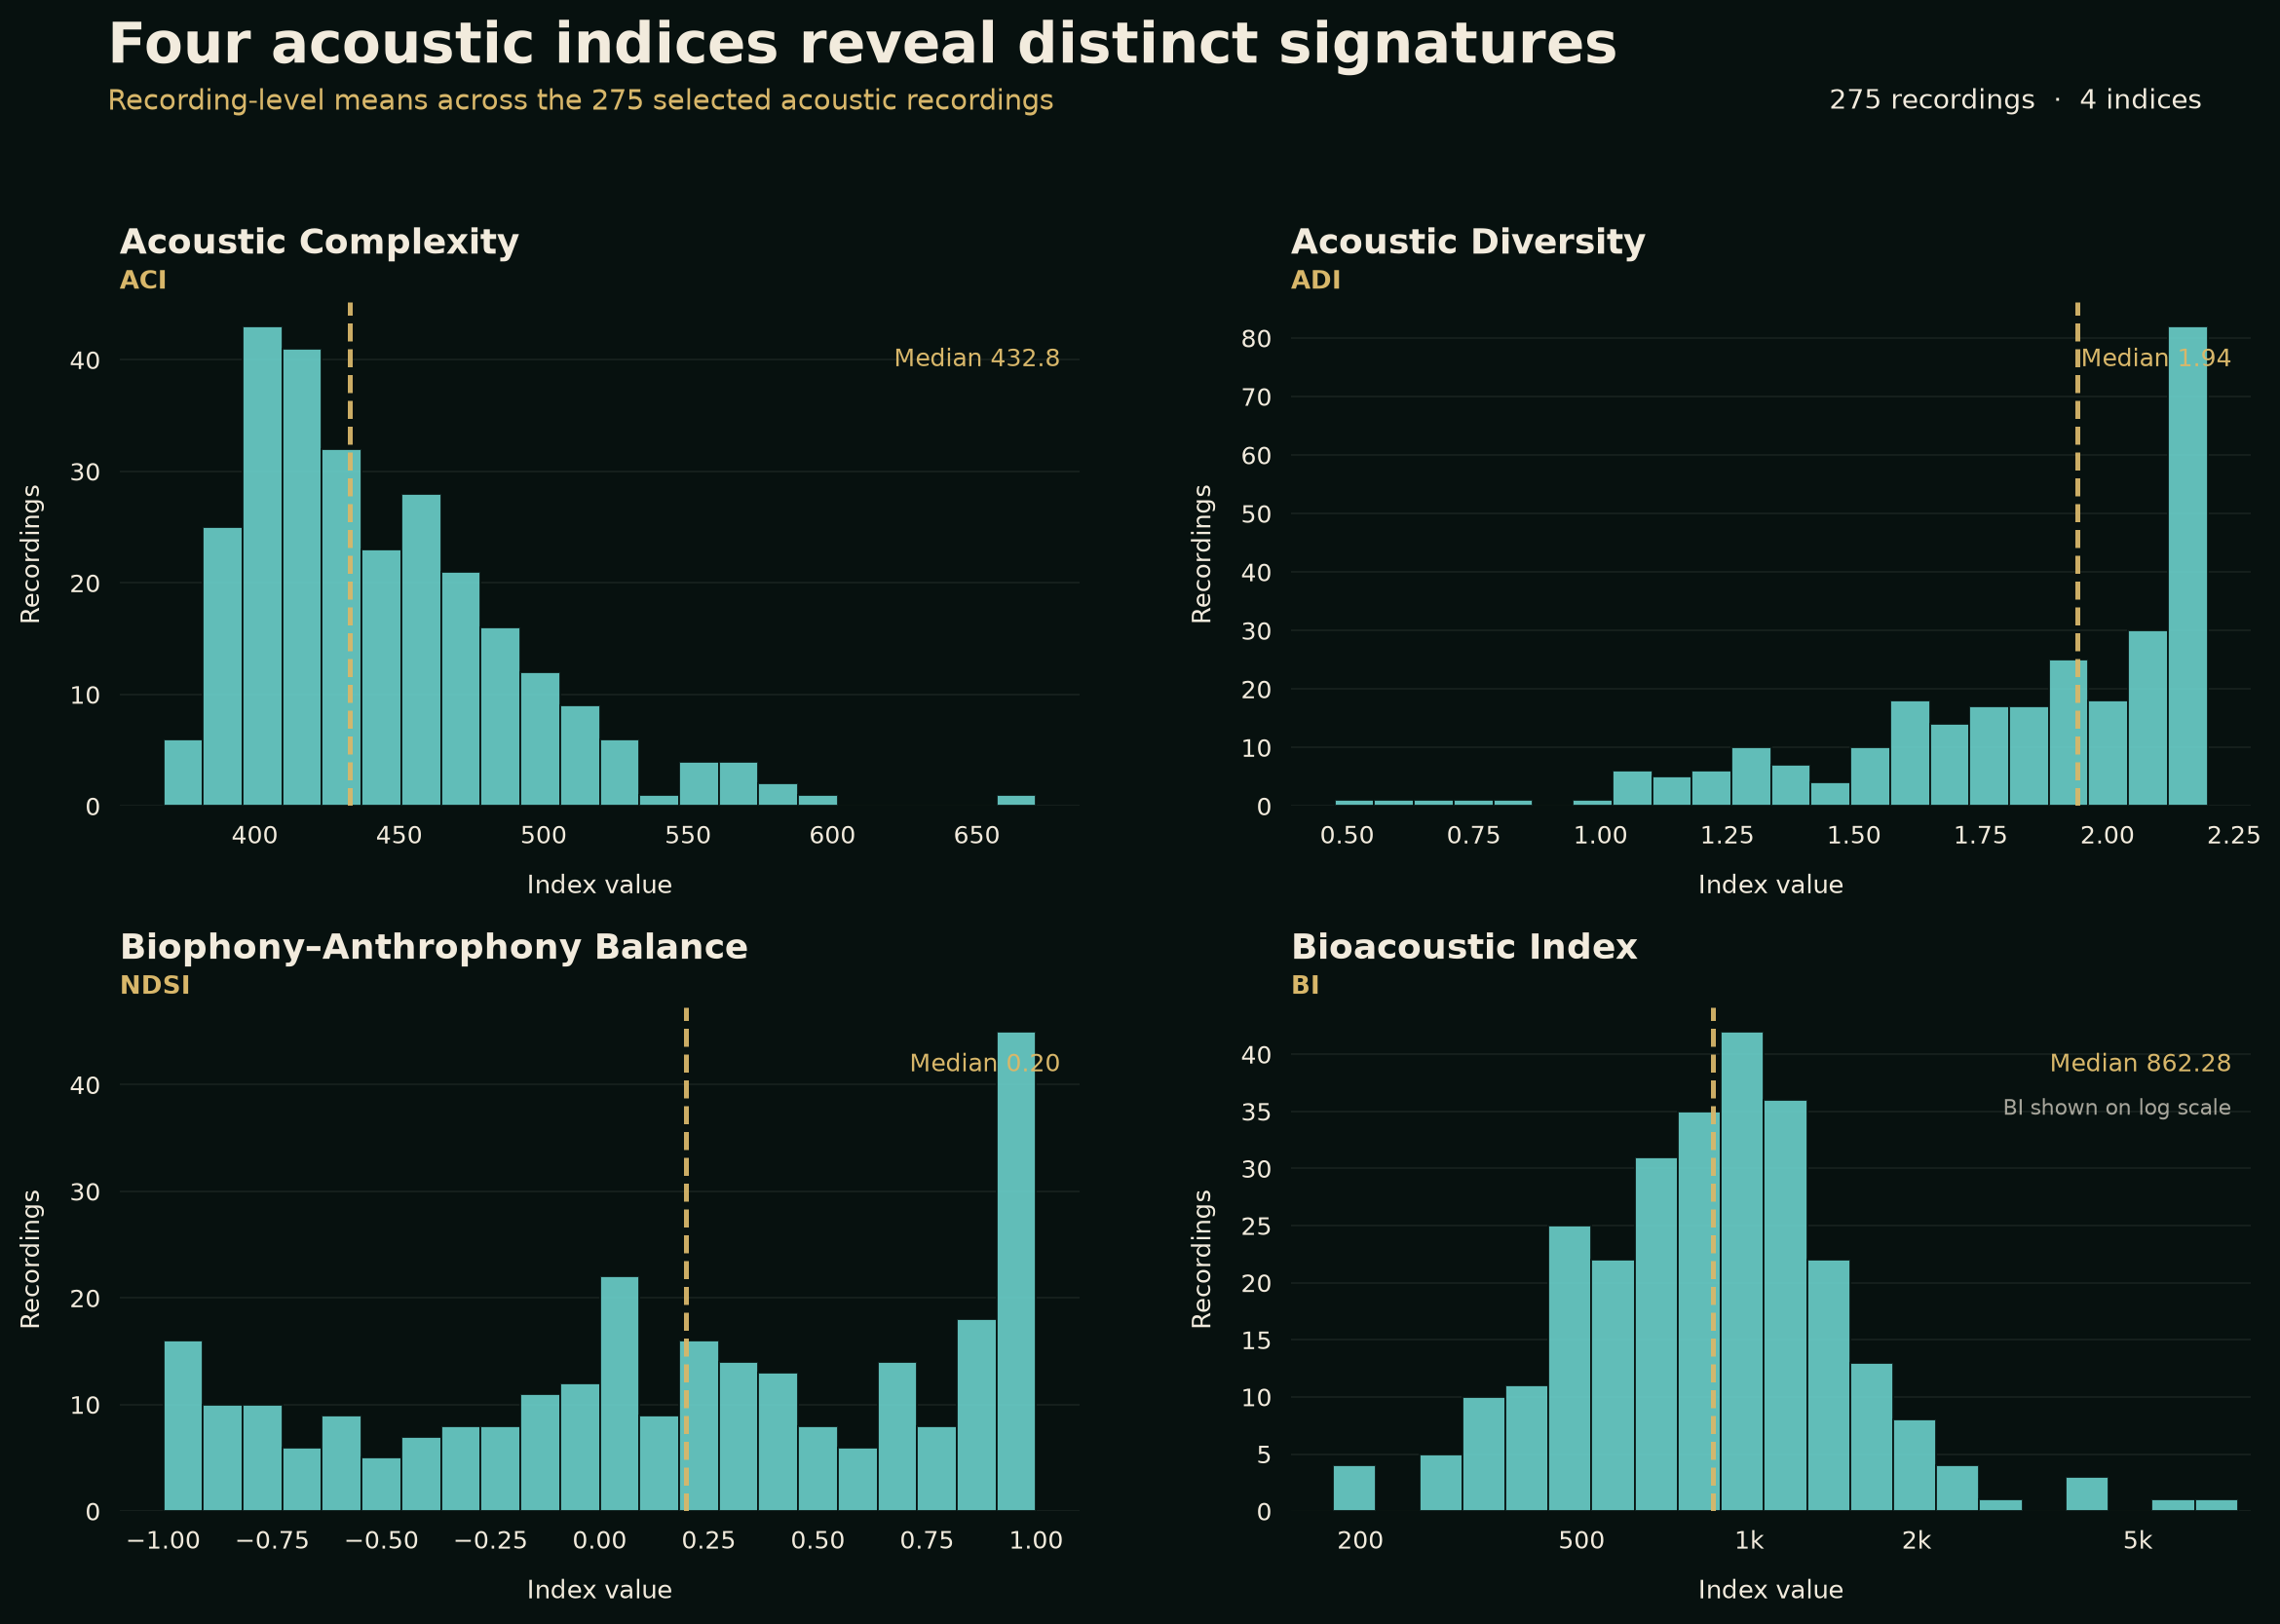

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\09_acoustic_indices.png


In [32]:
# ============================================================
# 29. Figure 09 — Acoustic index distributions
# ============================================================

from matplotlib.ticker import FixedLocator, FuncFormatter


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

index_specs = [
    {
        "column": "aci_mean",
        "title": "Acoustic Complexity",
        "label": "ACI",
        "median_decimals": 1,
        "log_x": False,
    },
    {
        "column": "adi_mean",
        "title": "Acoustic Diversity",
        "label": "ADI",
        "median_decimals": 2,
        "log_x": False,
    },
    {
        "column": "ndsi_mean",
        "title": "Biophony–Anthrophony Balance",
        "label": "NDSI",
        "median_decimals": 2,
        "log_x": False,
    },
    {
        "column": "bioacoustic_index_mean",
        "title": "Bioacoustic Index",
        "label": "BI",
        "median_decimals": 2,
        "log_x": True,
    },
]


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.5, 8.8),
    dpi=200
)

fig.patch.set_facecolor(
    EDA_STYLE["background"]
)

axes = axes.flatten()


# ------------------------------------------------------------
# Draw each acoustic-index distribution
# ------------------------------------------------------------

for ax, spec in zip(axes, index_specs):

    values = (
        features_eda[spec["column"]]
        .dropna()
        .to_numpy()
    )

    median_value = np.median(values)

    # --------------------------------------------------------
    # Histogram bins
    # --------------------------------------------------------

    if spec["log_x"]:

        bins = np.logspace(
            np.log10(values.min()),
            np.log10(values.max()),
            24
        )

    else:

        bins = 22


    # --------------------------------------------------------
    # Histogram
    # --------------------------------------------------------

    ax.hist(
        values,
        bins=bins,
        color=EDA_STYLE["cyan"],
        alpha=0.88,
        edgecolor=EDA_STYLE["background"],
        linewidth=0.7
    )


    # --------------------------------------------------------
    # Median reference
    # --------------------------------------------------------

    ax.axvline(
        median_value,
        color=EDA_STYLE["gold"],
        linewidth=1.8,
        linestyle="--",
        alpha=0.95,
        zorder=4
    )


    # --------------------------------------------------------
    # BI logarithmic axis
    # --------------------------------------------------------

    if spec["log_x"]:

        ax.set_xscale("log")

        # Intentionally sparse ticks.
        # The goal is readability rather than showing
        # every possible logarithmic tick.

        bi_ticks = [
            200,
            500,
            1000,
            2000,
            5000
        ]

        ax.xaxis.set_major_locator(
            FixedLocator(bi_ticks)
        )

        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: (
                    "1k" if x == 1000
                    else "2k" if x == 2000
                    else "5k" if x == 5000
                    else str(int(x))
                )
            )
        )

        # Remove minor logarithmic tick labels/marks.
        ax.xaxis.set_minor_locator(
            FixedLocator([])
        )

        # Keep the visible range focused on the actual
        # distribution rather than extending to 10k.
        ax.set_xlim(
            left=150,
            right=8000
        )


    # --------------------------------------------------------
    # Panel background
    # --------------------------------------------------------

    ax.set_facecolor(
        EDA_STYLE["background"]
    )


    # --------------------------------------------------------
    # Remove unnecessary borders
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_visible(False)


    # --------------------------------------------------------
    # Horizontal grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=EDA_STYLE["grid"],
        linewidth=0.7,
        alpha=0.42
    )

    ax.set_axisbelow(True)


    # --------------------------------------------------------
    # Tick styling
    # --------------------------------------------------------

    ax.tick_params(
        colors=EDA_STYLE["foreground"],
        labelsize=9,
        length=0,
        pad=7
    )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        "Index value",
        color=EDA_STYLE["foreground"],
        fontsize=9.5,
        labelpad=9
    )

    ax.set_ylabel(
        "Recordings",
        color=EDA_STYLE["foreground"],
        fontsize=9.5,
        labelpad=9
    )


    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.text(
        0,
        1.08,
        spec["title"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        color=EDA_STYLE["foreground"],
        fontsize=13,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # Short index identifier
    # --------------------------------------------------------

    ax.text(
        0,
        1.015,
        spec["label"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        color=EDA_STYLE["gold"],
        fontsize=9.5,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # Median annotation
    # --------------------------------------------------------

    median_text = (
        f"Median {median_value:.{spec['median_decimals']}f}"
    )

    ax.text(
        0.98,
        0.91,
        median_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        color=EDA_STYLE["gold"],
        fontsize=9
    )


    # --------------------------------------------------------
    # BI scale annotation
    # --------------------------------------------------------

    if spec["log_x"]:

        ax.text(
            0.98,
            0.82,
            "BI shown on log scale",
            transform=ax.transAxes,
            ha="right",
            va="top",
            color=EDA_STYLE["foreground"],
            fontsize=8,
            alpha=0.68
        )


# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.text(
    0.07,
    0.965,
    "Four acoustic indices reveal distinct signatures",
    ha="left",
    va="top",
    color=EDA_STYLE["foreground"],
    fontsize=21,
    fontweight="bold"
)


# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

fig.text(
    0.07,
    0.925,
    "Recording-level means across the 275 selected acoustic recordings",
    ha="left",
    va="top",
    color=EDA_STYLE["gold"],
    fontsize=10.5
)


# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

fig.text(
    0.93,
    0.925,
    "275 recordings  ·  4 indices",
    ha="right",
    va="top",
    color=EDA_STYLE["foreground"],
    fontsize=10
)


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.075,
    right=0.95,
    top=0.80,
    bottom=0.095,
    wspace=0.22,
    hspace=0.40
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = (
    EDA_FIGURES_DIR /
    "09_acoustic_indices.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** The four acoustic indices exhibit distinct distributional structures across the selected recordings. NDSI spans nearly its full bounded range, while the Bioacoustic Index is strongly right-skewed; a logarithmic x-axis is therefore used for BI to make variation across the distribution visible.

In [33]:
# ============================================================
# Statistical test — acoustic index differences across states
# ============================================================

from scipy.stats import kruskal

print("KRUSKAL-WALLIS TEST: ACOUSTIC INDICES ACROSS STATES")
print("=" * 60)
print("Non-parametric test for a difference in distribution across")
print("California, Arizona, and Texas. Small per-state samples (n=75-100)")
print("and an observational (non-experimental) design mean results should")
print("be read as descriptive evidence, not a controlled causal comparison.\n")

kruskal_results = []

for index_col in ["aci_mean", "adi_mean", "ndsi_mean", "bioacoustic_index_mean"]:
    groups = [
        features.loc[features["state"] == s, index_col].dropna()
        for s in ["AZ", "CA", "TX"]
    ]
    stat, p_value = kruskal(*groups)
    kruskal_results.append({"index": index_col, "H_statistic": stat, "p_value": p_value})
    print(f"{index_col:28} H = {stat:7.3f}   p = {p_value:.4f}   "
          f"{'(significant at alpha=0.05)' if p_value < 0.05 else '(not significant at alpha=0.05)'}")

kruskal_results_df = pd.DataFrame(kruskal_results)


KRUSKAL-WALLIS TEST: ACOUSTIC INDICES ACROSS STATES
Non-parametric test for a difference in distribution across
California, Arizona, and Texas. Small per-state samples (n=75-100)
and an observational (non-experimental) design mean results should
be read as descriptive evidence, not a controlled causal comparison.

aci_mean                     H =   1.495   p = 0.4735   (not significant at alpha=0.05)
adi_mean                     H =   0.423   p = 0.8095   (not significant at alpha=0.05)
ndsi_mean                    H =  24.675   p = 0.0000   (significant at alpha=0.05)
bioacoustic_index_mean       H =  14.571   p = 0.0007   (significant at alpha=0.05)


**Statistical note.** A Kruskal-Wallis test was used rather than ANOVA because the acoustic indices are not assumed to be normally distributed within each state. Results describe whether the three state samples are statistically distinguishable on each index; they do not establish a causal or ecological explanation for any difference found.

In [34]:
# ============================================================
# 30. Acoustic feature correlation audit
# ============================================================

print("ACOUSTIC FEATURE CORRELATION AUDIT")
print("=" * 60)

# Candidate interpretable acoustic features
correlation_candidates = [
    "aci_mean",
    "adi_mean",
    "ndsi_mean",
    "bioacoustic_index_mean",
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
    "temporal_entropy_mean",
    "spectral_entropy_eas_mean",
    "spectral_entropy_ecu_mean",
    "spectral_entropy_ecv_mean",
    "spectral_entropy_eps_mean",
]

available_features = [
    col
    for col in correlation_candidates
    if col in features_eda.columns
]

missing_features = [
    col
    for col in correlation_candidates
    if col not in features_eda.columns
]

print("\nAvailable features:")
for col in available_features:
    print("  ", col)

print("\nMissing expected features:")
for col in missing_features:
    print("  ", col)

print("\nNumber available:", len(available_features))

# ------------------------------------------------------------
# Correlation matrix
# ------------------------------------------------------------

correlation_matrix = (
    features_eda[available_features]
    .corr(method="spearman")
)

print("\nSpearman correlation matrix:")
display(
    correlation_matrix.round(2)
)

# ------------------------------------------------------------
# Strongest absolute correlations
# ------------------------------------------------------------

upper_triangle = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
)

strongest_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

strongest_pairs.columns = [
    "feature_1",
    "feature_2",
    "spearman_r"
]

strongest_pairs["abs_r"] = (
    strongest_pairs["spearman_r"].abs()
)

strongest_pairs = (
    strongest_pairs
    .sort_values(
        "abs_r",
        ascending=False
    )
)

print("\nStrongest feature relationships:")
display(
    strongest_pairs.head(15).round(3)
)

# ------------------------------------------------------------
# Missingness
# ------------------------------------------------------------

print("\nMissing values:")
print(
    features_eda[available_features]
    .isna()
    .sum()
)

ACOUSTIC FEATURE CORRELATION AUDIT

Available features:
   aci_mean
   adi_mean
   ndsi_mean
   bioacoustic_index_mean
   temporal_entropy_mean
   spectral_entropy_eas_mean
   spectral_entropy_ecu_mean
   spectral_entropy_ecv_mean
   spectral_entropy_eps_mean

Missing expected features:
   rms_mean
   zcr_mean
   spectral_centroid_mean
   spectral_bandwidth_mean
   spectral_rolloff_mean

Number available: 9

Spearman correlation matrix:


,aci_mean,adi_mean,ndsi_mean,bioacoustic_index_mean,temporal_entropy_mean,spectral_entropy_eas_mean,spectral_entropy_ecu_mean,spectral_entropy_ecv_mean,spectral_entropy_eps_mean
aci_mean,1.00,-0.12,0.47,0.46,-0.37,-0.09,-0.15,-0.25,-0.26
adi_mean,-0.12,1.00,-0.09,-0.32,0.31,-0.74,-0.55,-0.63,-0.14
ndsi_mean,0.47,-0.09,1.00,0.25,-0.46,0.03,-0.10,-0.06,-0.39
bioacoustic_index_mean,0.46,-0.32,0.25,1.00,0.00,0.07,-0.04,-0.05,-0.11
temporal_entropy_mean,-0.37,0.31,-0.46,0.00,1.00,-0.22,-0.14,-0.13,0.19
spectral_entropy_eas_mean,-0.09,-0.74,0.03,0.07,-0.22,1.00,0.78,0.88,0.28
spectral_entropy_ecu_mean,-0.15,-0.55,-0.10,-0.04,-0.14,0.78,1.00,0.89,0.26
spectral_entropy_ecv_mean,-0.25,-0.63,-0.06,-0.05,-0.13,0.88,0.89,1.00,0.21
spectral_entropy_eps_mean,-0.26,-0.14,-0.39,-0.11,0.19,0.28,0.26,0.21,1.00



Strongest feature relationships:


,feature_1,feature_2,spearman_r,abs_r
33,spectral_entropy_ecu_mean,spectral_entropy_ecv_mean,0.888,0.888
31,spectral_entropy_eas_mean,spectral_entropy_ecv_mean,0.878,0.878
30,spectral_entropy_eas_mean,spectral_entropy_ecu_mean,0.777,0.777
11,adi_mean,spectral_entropy_eas_mean,-0.743,0.743
13,adi_mean,spectral_entropy_ecv_mean,-0.633,0.633
12,adi_mean,spectral_entropy_ecu_mean,-0.548,0.548
1,aci_mean,ndsi_mean,0.473,0.473
2,aci_mean,bioacoustic_index_mean,0.460,0.460
16,ndsi_mean,temporal_entropy_mean,-0.459,0.459
20,ndsi_mean,spectral_entropy_eps_mean,-0.394,0.394



Missing values:
aci_mean                     0
adi_mean                     0
ndsi_mean                    0
bioacoustic_index_mean       0
temporal_entropy_mean        0
spectral_entropy_eas_mean    0
spectral_entropy_ecu_mean    0
spectral_entropy_ecv_mean    0
spectral_entropy_eps_mean    0
dtype: int64


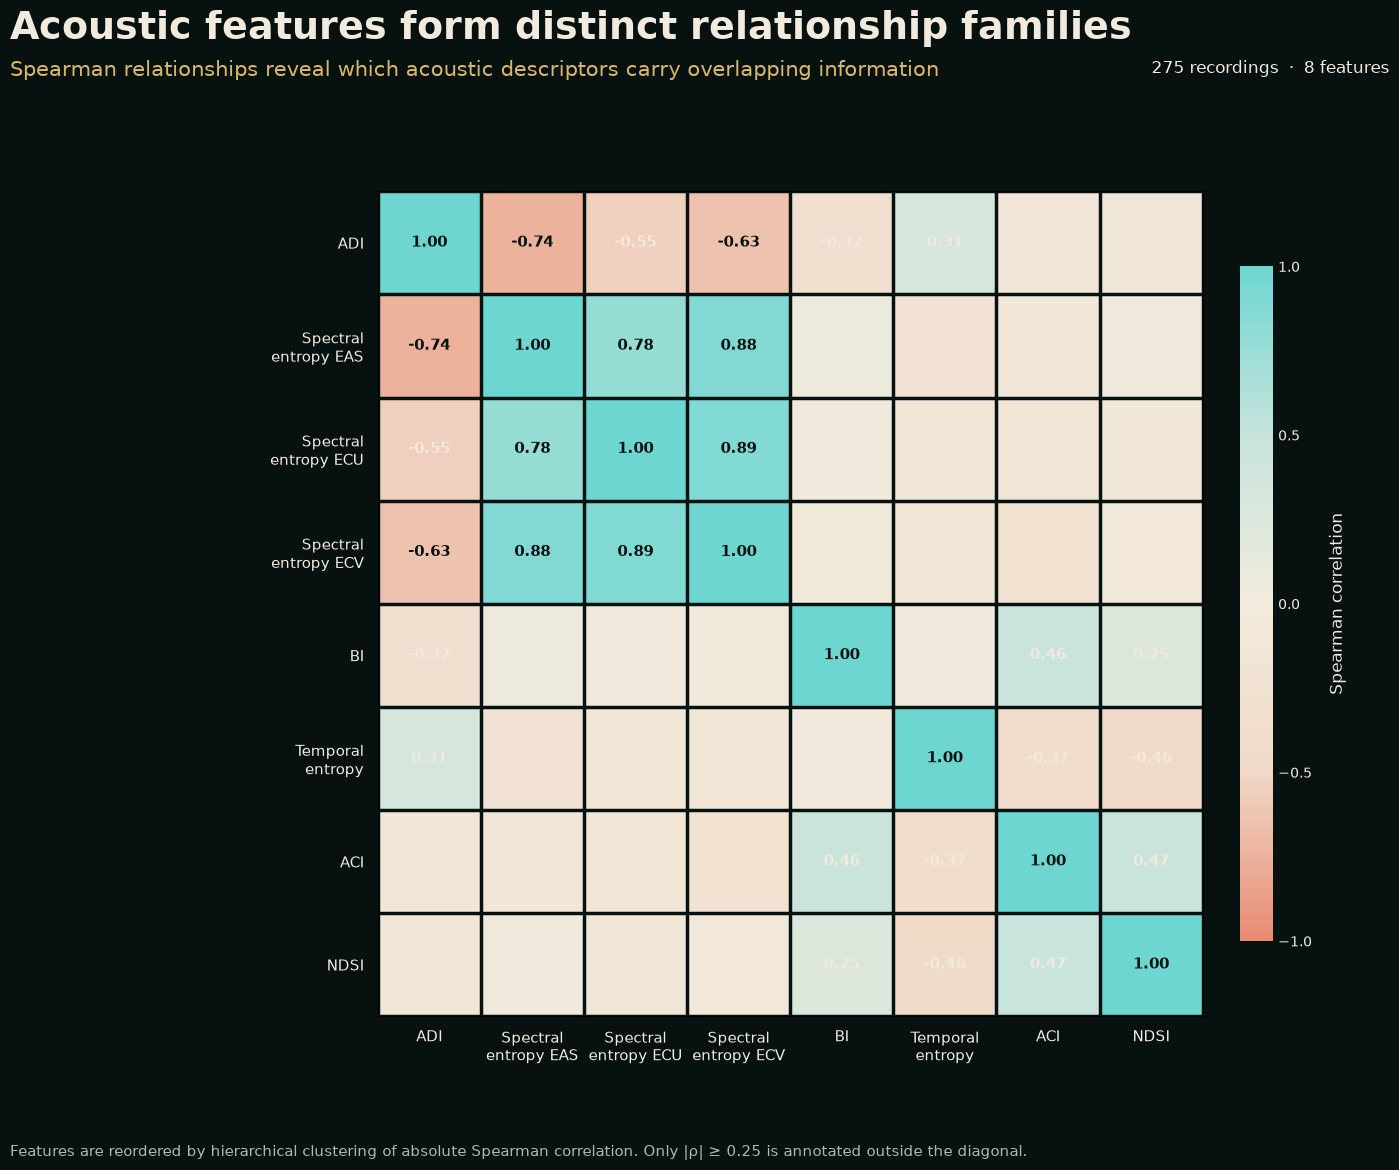

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\10_feature_correlation.png


In [35]:
# ============================================================
# 24. Acoustic feature correlation — final website figure
# ============================================================

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Feature set
# ------------------------------------------------------------

correlation_features = [
    "aci_mean",
    "adi_mean",
    "ndsi_mean",
    "bioacoustic_index_mean",
    "temporal_entropy_mean",
    "spectral_entropy_eas_mean",
    "spectral_entropy_ecu_mean",
    "spectral_entropy_ecv_mean",
]

feature_labels = {
    "aci_mean": "ACI",
    "adi_mean": "ADI",
    "ndsi_mean": "NDSI",
    "bioacoustic_index_mean": "BI",
    "temporal_entropy_mean": "Temporal\nentropy",
    "spectral_entropy_eas_mean": "Spectral\nentropy EAS",
    "spectral_entropy_ecu_mean": "Spectral\nentropy ECU",
    "spectral_entropy_ecv_mean": "Spectral\nentropy ECV",
}

# ------------------------------------------------------------
# Spearman correlation
# ------------------------------------------------------------

corr = (
    features_eda[correlation_features]
    .corr(method="spearman")
)

# ------------------------------------------------------------
# Hierarchical ordering
# ------------------------------------------------------------

distance_matrix = 1 - np.abs(corr.values)

np.fill_diagonal(distance_matrix, 0)

linkage_matrix = linkage(
    squareform(distance_matrix, checks=False),
    method="average"
)

ordered_idx = leaves_list(linkage_matrix)

ordered_features = [
    correlation_features[i]
    for i in ordered_idx
]

corr_ordered = corr.loc[
    ordered_features,
    ordered_features
]

ordered_labels = [
    feature_labels[f]
    for f in ordered_features
]

# ------------------------------------------------------------
# Website palette
# ------------------------------------------------------------

BG = "#07110f"
CREAM = "#f2ebdd"
GOLD = "#d8b76a"
CYAN = "#6ed6d1"
CORAL = "#e88b72"
MUTED = "#aeb8b3"

# ------------------------------------------------------------
# Custom diverging colormap
#
# Negative correlation -> coral
# Zero correlation     -> warm cream
# Positive correlation -> cyan
# ------------------------------------------------------------

correlation_cmap = LinearSegmentedColormap.from_list(
    "acoustic_correlation",
    [
        CORAL,
        "#f0d9c7",
        CREAM,
        "#c7e4dc",
        CYAN,
    ]
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15.5, 12.5),
    facecolor=BG
)

ax.set_facecolor(BG)

im = ax.imshow(
    corr_ordered.values,
    cmap=correlation_cmap,
    vmin=-1,
    vmax=1,
    aspect="equal"
)

# ------------------------------------------------------------
# Cell boundaries
# ------------------------------------------------------------

n_features = len(ordered_features)

for i in range(n_features + 1):
    ax.axhline(
        i - 0.5,
        color=BG,
        linewidth=2.5
    )
    ax.axvline(
        i - 0.5,
        color=BG,
        linewidth=2.5
    )

# ------------------------------------------------------------
# Correlation annotations
#
# Only meaningful relationships are labelled.
# Diagonal values are always retained.
# ------------------------------------------------------------

for i in range(n_features):
    for j in range(n_features):

        value = corr_ordered.iloc[i, j]

        if i == j or abs(value) >= 0.25:

            # Strong cells need dark text.
            # Pale cells need cream text.
            if abs(value) >= 0.55:
                text_color = BG
            else:
                text_color = CREAM

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10.5,
                fontweight="bold",
                color=text_color
            )

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(np.arange(n_features))
ax.set_yticks(np.arange(n_features))

ax.set_xticklabels(
    ordered_labels,
    fontsize=10.5,
    color=CREAM,
    ha="center"
)

ax.set_yticklabels(
    ordered_labels,
    fontsize=11,
    color=CREAM
)

ax.tick_params(
    axis="both",
    length=0,
    pad=10
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.032,
    pad=0.035
)

cbar.set_label(
    "Spearman correlation",
    color=CREAM,
    fontsize=12,
    labelpad=12
)

cbar.set_ticks(
    [-1, -0.5, 0, 0.5, 1]
)

cbar.ax.tick_params(
    colors=CREAM,
    length=0,
    labelsize=10
)

cbar.outline.set_visible(False)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

fig.text(
    0.055,
    0.965,
    "Acoustic features form distinct relationship families",
    fontsize=27,
    fontweight="bold",
    color=CREAM,
    ha="left",
    va="top"
)

fig.text(
    0.055,
    0.925,
    "Spearman relationships reveal which acoustic descriptors carry overlapping information",
    fontsize=15,
    color=GOLD,
    ha="left",
    va="top"
)

# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

fig.text(
    0.945,
    0.925,
    f"{len(features_eda):,} recordings  ·  "
    f"{len(correlation_features)} features",
    fontsize=12,
    color=CREAM,
    ha="right",
    va="top"
)

# ------------------------------------------------------------
# Interpretation note
# ------------------------------------------------------------

fig.text(
    0.055,
    0.045,
    "Features are reordered by hierarchical clustering of absolute Spearman correlation. "
    "Only |ρ| ≥ 0.25 is annotated outside the diagonal.",
    fontsize=10.5,
    color=MUTED,
    ha="left",
    va="bottom"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.19,
    right=0.87,
    top=0.82,
    bottom=0.16
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

correlation_figure_path = (
    EDA_FIGURES_DIR / "10_feature_correlation.png"
)

fig.savefig(
    correlation_figure_path,
    dpi=220,
    facecolor=BG,
    bbox_inches="tight"
)

plt.show()

print("Saved:", correlation_figure_path)

**Figure interpretation.** The four spectral-entropy variants are strongly intercorrelated (Spearman r = 0.78-0.89), as expected since they are related mathematical decompositions of the same spectral information. Among the ecological indices, ADI shows a strong negative relationship with spectral entropy (r = -0.74) and a moderate positive relationship between ACI and NDSI (r = 0.47), suggesting these indices capture partially distinct but related structure.

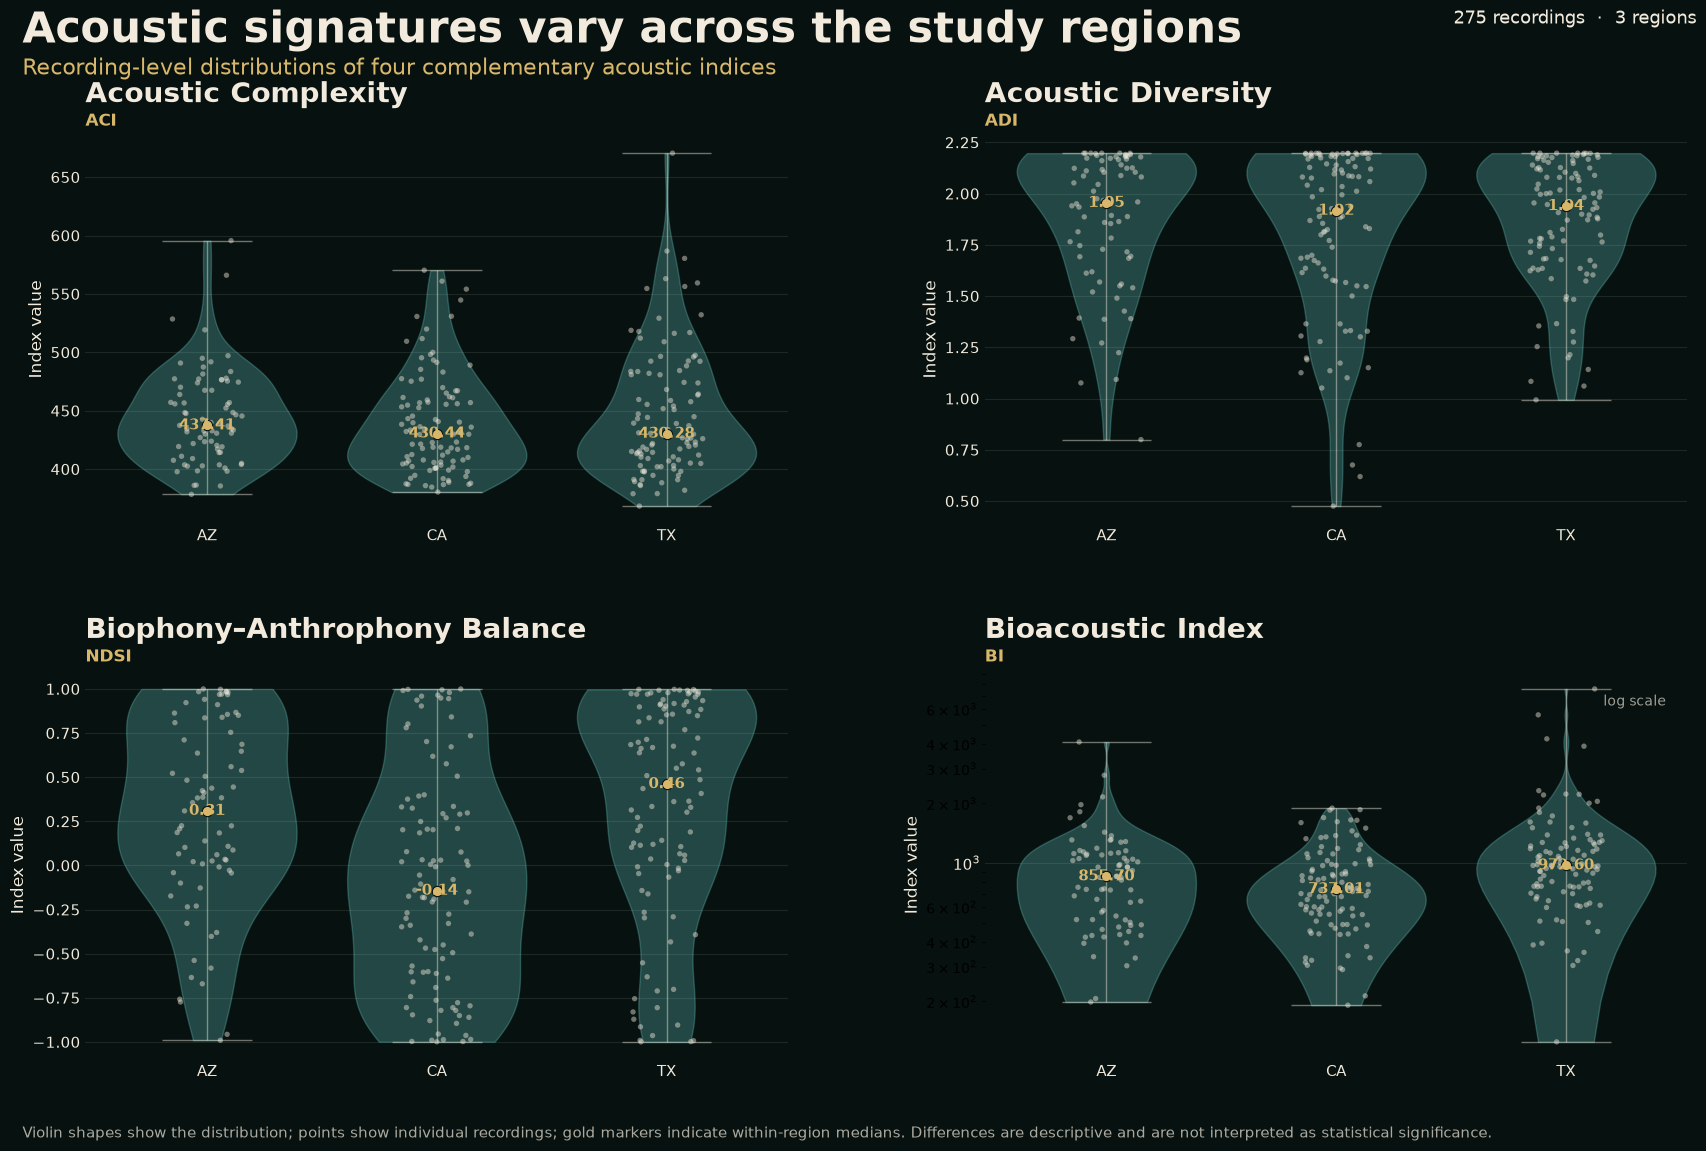

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\11_state_acoustic_distributions.png


In [36]:
# ============================================================
# 23. Acoustic index distributions by state
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

index_configs = [
    {
        "column": "aci_mean",
        "title": "Acoustic Complexity",
        "short": "ACI",
        "ylabel": "Index value",
        "log_scale": False,
    },
    {
        "column": "adi_mean",
        "title": "Acoustic Diversity",
        "short": "ADI",
        "ylabel": "Index value",
        "log_scale": False,
    },
    {
        "column": "ndsi_mean",
        "title": "Biophony–Anthrophony Balance",
        "short": "NDSI",
        "ylabel": "Index value",
        "log_scale": False,
    },
    {
        "column": "bioacoustic_index_mean",
        "title": "Bioacoustic Index",
        "short": "BI",
        "ylabel": "Index value",
        "log_scale": True,
    },
]

states = ["AZ", "CA", "TX"]

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

BG = EDA_STYLE["background"]
FG = EDA_STYLE["foreground"]
GOLD = EDA_STYLE["gold"]
CYAN = EDA_STYLE["cyan"]
GRID = EDA_STYLE["grid"]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    facecolor=BG
)

axes = axes.flatten()

# ------------------------------------------------------------
# Plot each acoustic index
# ------------------------------------------------------------

for ax, config in zip(axes, index_configs):

    column = config["column"]

    # --------------------------------------------------------
    # Extract state-level values
    # --------------------------------------------------------

    state_values = [
        features_eda.loc[
            features_eda["state"] == state,
            column
        ].dropna().values
        for state in states
    ]

    # --------------------------------------------------------
    # Violin distributions
    # --------------------------------------------------------

    parts = ax.violinplot(
        state_values,
        positions=np.arange(1, len(states) + 1),
        widths=0.78,
        showmeans=False,
        showmedians=False,
        showextrema=True
    )

    for body in parts["bodies"]:
        body.set_facecolor(CYAN)
        body.set_edgecolor(CYAN)
        body.set_alpha(0.28)

    # Make extrema / whiskers subtle
    for key in ["cbars", "cmins", "cmaxes", "cmedians"]:
        if key in parts:
            parts[key].set_color(FG)
            parts[key].set_alpha(0.45)
            parts[key].set_linewidth(1.0)

    # --------------------------------------------------------
    # Individual recording points
    # --------------------------------------------------------

    rng = np.random.default_rng(42)

    for i, values in enumerate(state_values, start=1):

        if len(values) == 0:
            continue

        jitter = rng.uniform(
            -0.16,
            0.16,
            size=len(values)
        )

        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            s=15,
            alpha=0.45,
            color=FG,
            edgecolors="none",
            zorder=3
        )

    # --------------------------------------------------------
    # Within-state medians
    # --------------------------------------------------------

    for i, values in enumerate(state_values, start=1):

        if len(values) == 0:
            continue

        median_value = np.median(values)

        ax.scatter(
            i,
            median_value,
            s=55,
            color=GOLD,
            edgecolors=BG,
            linewidth=0.8,
            zorder=5
        )

        # Median label
        ax.text(
            i,
            median_value,
            f"{median_value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=GOLD,
            zorder=6
        )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_xticks(range(1, len(states) + 1))
    ax.set_xticklabels(
        states,
        fontsize=12,
        color=FG
    )

    ax.set_ylabel(
        config["ylabel"],
        fontsize=12,
        color=FG
    )

    # --------------------------------------------------------
    # Logarithmic scale for BI
    # --------------------------------------------------------

    if config["log_scale"]:
        ax.set_yscale("log")

        ax.text(
            0.97,
            0.94,
            "log scale",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            color=FG,
            alpha=0.65
        )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        config["title"],
        loc="left",
        fontsize=20,
        fontweight="bold",
        color=FG,
        pad=24
    )

    # --------------------------------------------------------
    # Short index label
    # Positioned BELOW title, not overlapping it
    # --------------------------------------------------------

    ax.text(
        0.0,
        1.015,
        config["short"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=GOLD
    )

    # --------------------------------------------------------
    # Grid / styling
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=GRID,
        alpha=0.65,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        colors=FG,
        labelsize=11,
        length=0
    )

    ax.set_facecolor(BG)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.text(
    0.035,
    0.965,
    "Acoustic signatures vary across the study regions",
    fontsize=31,
    fontweight="bold",
    color=FG,
    ha="left",
    va="top"
)

fig.text(
    0.035,
    0.925,
    "Recording-level distributions of four complementary acoustic indices",
    fontsize=16,
    color=GOLD,
    ha="left",
    va="top"
)

fig.text(
    0.965,
    0.965,
    "275 recordings  ·  3 regions",
    fontsize=13,
    color=FG,
    ha="right",
    va="top"
)

# ------------------------------------------------------------
# Figure interpretation note
# ------------------------------------------------------------

fig.text(
    0.035,
    0.025,
    "Violin shapes show the distribution; points show individual recordings; "
    "gold markers indicate within-region medians. "
    "Differences are descriptive and are not interpreted as statistical significance.",
    fontsize=10.5,
    color=FG,
    alpha=0.70,
    ha="left"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.07,
    right=0.96,
    top=0.86,
    bottom=0.09,
    wspace=0.28,
    hspace=0.38
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = (
    EDA_FIGURES_DIR /
    "11_state_acoustic_distributions.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

**Figure interpretation.** Acoustic index distributions show broadly similar shapes across California, Arizona, and Texas, with no state showing an extreme outlier distribution. Any differences visible here should be interpreted alongside the Kruskal-Wallis test above rather than by visual inspection alone.

QC FEATURE VALIDATION
Missing required columns: []

QC status counts:
Clean:        208
Audit flagged: 67


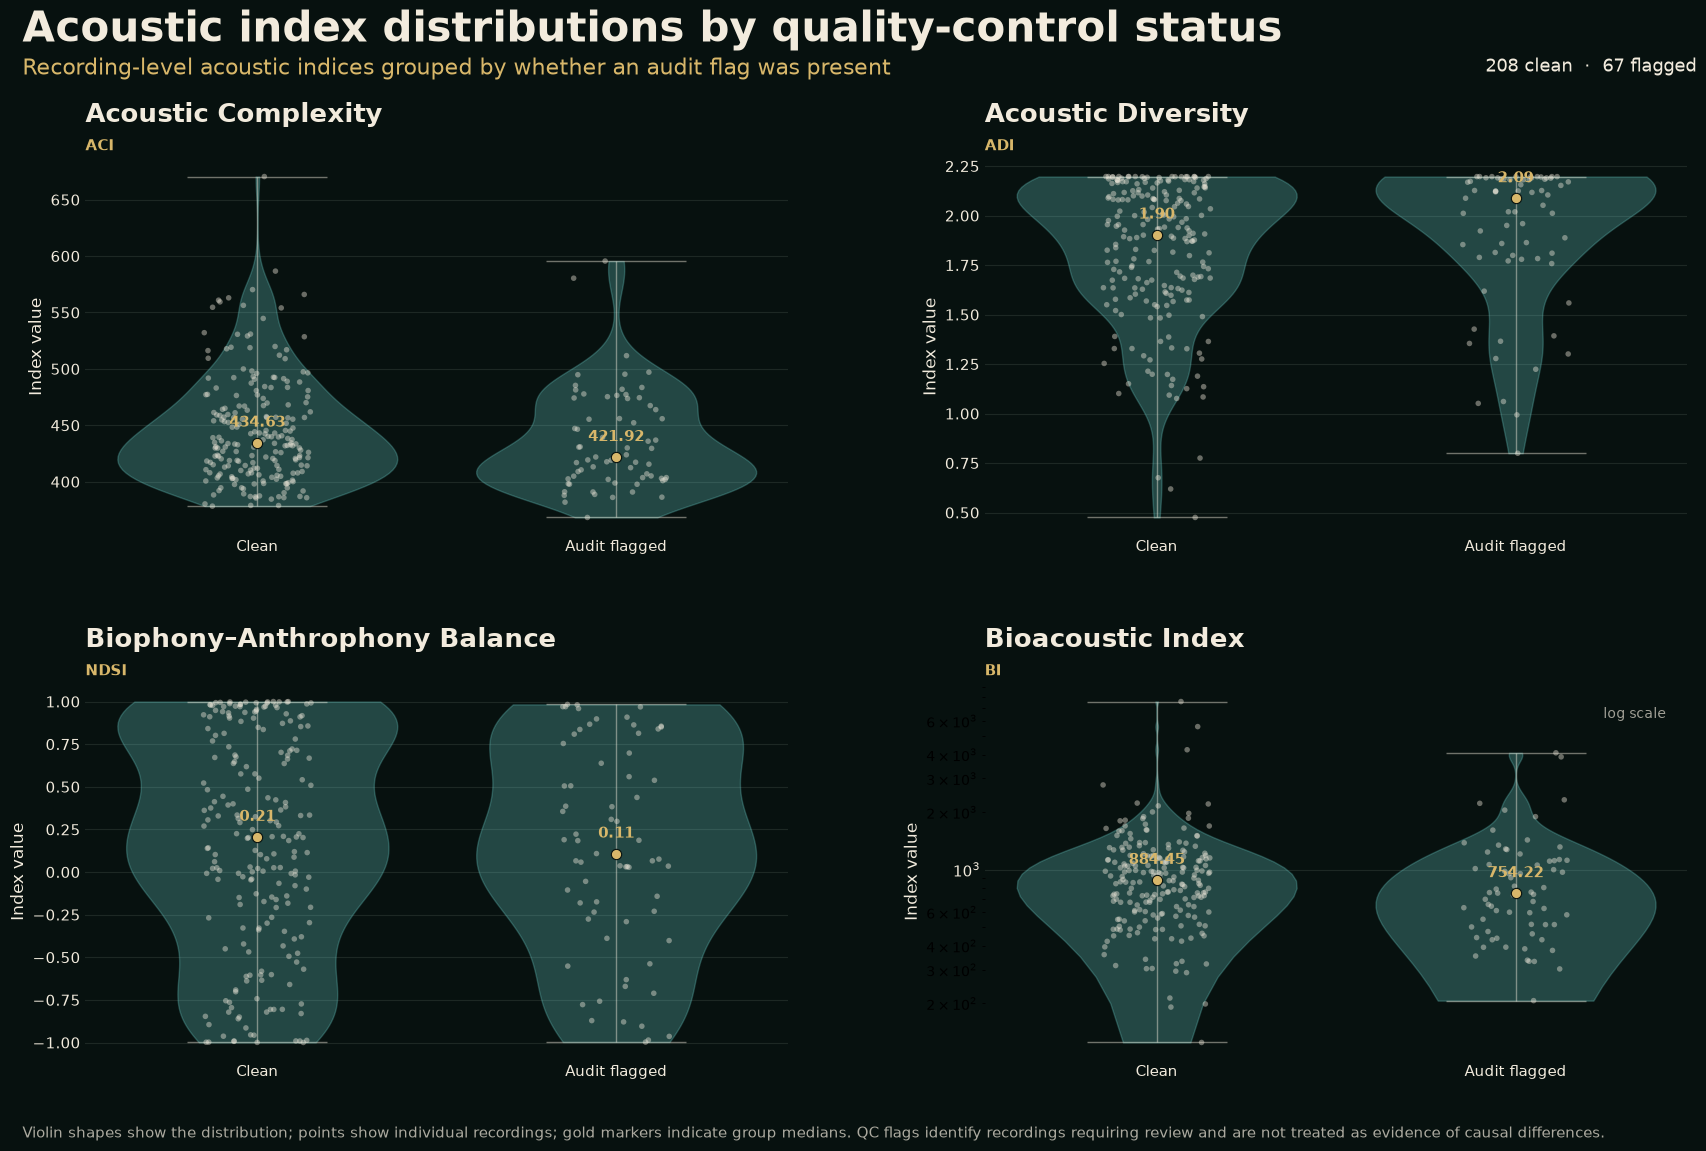


Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\12_qc_comparison.png


In [37]:
# ============================================================
# 24. Acoustic feature distributions by QC status
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

qc_configs = [
    {
        "column": "aci_mean",
        "title": "Acoustic Complexity",
        "short": "ACI",
        "log_scale": False,
    },
    {
        "column": "adi_mean",
        "title": "Acoustic Diversity",
        "short": "ADI",
        "log_scale": False,
    },
    {
        "column": "ndsi_mean",
        "title": "Biophony–Anthrophony Balance",
        "short": "NDSI",
        "log_scale": False,
    },
    {
        "column": "bioacoustic_index_mean",
        "title": "Bioacoustic Index",
        "short": "BI",
        "log_scale": True,
    },
]

qc_groups = [
    ("Clean", False),
    ("Audit flagged", True),
]

# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------

required_qc_columns = [
    "recording_id",
    "flag_any",
    "aci_mean",
    "adi_mean",
    "ndsi_mean",
    "bioacoustic_index_mean",
]

missing_qc_columns = [
    col
    for col in required_qc_columns
    if col not in features_eda.columns
]

print("QC FEATURE VALIDATION")
print("=" * 60)

print("Missing required columns:", missing_qc_columns)

assert len(missing_qc_columns) == 0

# ------------------------------------------------------------
# QC counts
# ------------------------------------------------------------

n_clean = int(
    (~features_eda["flag_any"]).sum()
)

n_flagged = int(
    features_eda["flag_any"].sum()
)

print("\nQC status counts:")
print(f"Clean:        {n_clean}")
print(f"Audit flagged: {n_flagged}")

assert n_clean + n_flagged == len(features_eda)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    facecolor=BG
)

axes = axes.flatten()

rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Plot each acoustic index
# ------------------------------------------------------------

for ax, config in zip(axes, qc_configs):

    column = config["column"]

    group_values = []

    for label, flag_status in qc_groups:

        values = (
            features_eda.loc[
                features_eda["flag_any"] == flag_status,
                column
            ]
            .dropna()
            .values
        )

        group_values.append(values)

    # --------------------------------------------------------
    # Violin distributions
    # --------------------------------------------------------

    parts = ax.violinplot(
        group_values,
        positions=[1, 2],
        widths=0.78,
        showmeans=False,
        showmedians=False,
        showextrema=True
    )

    for body in parts["bodies"]:
        body.set_facecolor(CYAN)
        body.set_edgecolor(CYAN)
        body.set_alpha(0.28)

    for key in ["cbars", "cmins", "cmaxes", "cmedians"]:
        if key in parts:
            parts[key].set_color(FG)
            parts[key].set_alpha(0.45)
            parts[key].set_linewidth(1.0)

    # --------------------------------------------------------
    # Individual recordings
    # --------------------------------------------------------

    for position, values in zip([1, 2], group_values):

        if len(values) == 0:
            continue

        jitter = rng.uniform(
            -0.15,
            0.15,
            size=len(values)
        )

        ax.scatter(
            np.full(len(values), position) + jitter,
            values,
            s=16,
            alpha=0.42,
            color=FG,
            edgecolors="none",
            zorder=3
        )

    # --------------------------------------------------------
    # Group medians
    # --------------------------------------------------------

    for position, values in zip([1, 2], group_values):

        if len(values) == 0:
            continue

        median_value = np.median(values)

        ax.scatter(
            position,
            median_value,
            s=55,
            color=GOLD,
            edgecolors=BG,
            linewidth=0.8,
            zorder=5
        )

        # Place median text slightly above the marker
        # to avoid excessive overlap with observations.
        ax.annotate(
            f"{median_value:.2f}",
            xy=(position, median_value),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color=GOLD,
            zorder=6
        )

    # --------------------------------------------------------
    # X axis
    # --------------------------------------------------------

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        [label for label, _ in qc_groups],
        fontsize=12,
        color=FG
    )

    # --------------------------------------------------------
    # Y axis
    # --------------------------------------------------------

    ax.set_ylabel(
        "Index value",
        fontsize=12,
        color=FG
    )

    # --------------------------------------------------------
    # BI logarithmic scale
    # --------------------------------------------------------

    if config["log_scale"]:

        ax.set_yscale("log")

        ax.text(
            0.97,
            0.94,
            "log scale",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            color=FG,
            alpha=0.65
        )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        config["title"],
        loc="left",
        fontsize=19,
        fontweight="bold",
        color=FG,
        pad=27
    )

    # --------------------------------------------------------
    # Acoustic index abbreviation
    # --------------------------------------------------------

    ax.text(
        0.0,
        1.015,
        config["short"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=GOLD
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        color=GRID,
        alpha=0.65,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    # --------------------------------------------------------
    # Spines / ticks
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        colors=FG,
        labelsize=11,
        length=0
    )

    ax.set_facecolor(BG)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.text(
    0.035,
    0.965,
    "Acoustic index distributions by quality-control status",
    fontsize=30,
    fontweight="bold",
    color=FG,
    ha="left",
    va="top"
)

# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

fig.text(
    0.035,
    0.925,
    "Recording-level acoustic indices grouped by whether an audit flag was present",
    fontsize=16,
    color=GOLD,
    ha="left",
    va="top"
)

# ------------------------------------------------------------
# QC summary
# Put it below the subtitle so it cannot collide with title.
# ------------------------------------------------------------

fig.text(
    0.965,
    0.925,
    f"{n_clean} clean  ·  {n_flagged} flagged",
    fontsize=13,
    color=FG,
    ha="right",
    va="top"
)

# ------------------------------------------------------------
# Interpretation note
# ------------------------------------------------------------

fig.text(
    0.035,
    0.025,
    "Violin shapes show the distribution; points show individual recordings; "
    "gold markers indicate group medians. "
    "QC flags identify recordings requiring review and are not treated as evidence of causal differences.",
    fontsize=10.5,
    color=FG,
    alpha=0.70,
    ha="left"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.07,
    right=0.96,
    top=0.84,
    bottom=0.09,
    wspace=0.28,
    hspace=0.40
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = (
    EDA_FIGURES_DIR /
    "12_qc_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

print("\nSaved:", figure_path)

**Figure interpretation.** Of 275 recordings, 208 passed all audit checks and 67 were flagged during quality control (short duration, low amplitude, or clipping). Comparing acoustic index distributions between these two groups provides an empirical check on whether the audit flags correspond to measurably different acoustic content, rather than serving as an arbitrary label.

In [38]:
# ============================================================
# 25A. Inspect columns needed for Figure 13
# ============================================================

print("COLUMNS IN features_eda")
print("=" * 60)

for i, col in enumerate(features_eda.columns):
    print(i, col)

print("\nWINDOW-RELATED COLUMNS")
print("=" * 60)

for col in features_eda.columns:
    if (
        "window" in col.lower()
        or "duration" in col.lower()
    ):
        print(col)

COLUMNS IN features_eda
0 recording_id
1 state
2 species_id
3 common_name
4 scientific_name
5 original_sample_rate
6 original_channels
7 flag_short_duration
8 flag_low_amplitude
9 flag_clipping
10 flag_low_quality
11 flag_any
12 flag_bandlimit_incompatible
13 n_windows
14 aci_mean
15 adi_mean
16 bioacoustic_index_mean
17 ndsi_mean
18 ndsi_ratio_ba_mean
19 anthropophony_mean
20 biophony_mean
21 spectral_entropy_eas_mean
22 spectral_entropy_ecu_mean
23 spectral_entropy_ecv_mean
24 spectral_entropy_eps_mean
25 spectral_entropy_eps_kurt_mean
26 spectral_entropy_eps_skew_mean
27 temporal_entropy_mean
28 rms_mean_mean
29 rms_std_mean
30 zcr_mean_mean
31 zcr_std_mean
32 spectral_centroid_mean_mean
33 spectral_centroid_std_mean
34 spectral_bandwidth_mean_mean
35 spectral_bandwidth_std_mean
36 spectral_rolloff_mean_mean
37 spectral_rolloff_std_mean
38 mfcc_01_mean
39 mfcc_01_within_std_mean
40 mfcc_02_mean
41 mfcc_02_within_std_mean
42 mfcc_03_mean
43 mfcc_03_within_std_mean
44 mfcc_04_mean
45 

In [39]:
# ============================================================
# 25. Window structure audit
# ============================================================

print("WINDOW STRUCTURE AUDIT")
print("=" * 60)

# Verify the columns actually needed for this analysis
required_window_columns = [
    "recording_id",
    "state",
    "n_windows",
    "single_window",
]

missing_window_columns = [
    col for col in required_window_columns
    if col not in features_eda.columns
]

print("Missing required columns:", missing_window_columns)

assert len(missing_window_columns) == 0

# ------------------------------------------------------------
# Window-count summary
# ------------------------------------------------------------

window_summary = (
    features_eda["n_windows"]
    .value_counts()
    .sort_index()
)

print("\nAnalysis windows per recording:")
print(window_summary)

print("\nRecordings by window structure:")
print(
    features_eda["single_window"]
    .value_counts()
    .rename(index={
        True: "Single-window",
        False: "Multi-window"
    })
)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

single_window_check = (
    (features_eda["n_windows"] == 1)
    == features_eda["single_window"].astype(bool)
)

print("\nConsistency check:")
print(
    "single_window agrees with n_windows:",
    single_window_check.all()
)

assert single_window_check.all()

print("\nTotal recordings:", len(features_eda))
print(
    "Single-window recordings:",
    int(features_eda["single_window"].sum())
)
print(
    "Multi-window recordings:",
    int((~features_eda["single_window"].astype(bool)).sum())
)

print("\nMaximum analysis windows in one recording:",
      int(features_eda["n_windows"].max()))

WINDOW STRUCTURE AUDIT
Missing required columns: []

Analysis windows per recording:
n_windows
1     117
2      39
3      25
4      22
5      15
6      12
7       7
8       5
9       1
10      4
11      5
12      2
13      1
14      2
15      3
16      3
17      1
18      1
19      1
20      1
21      1
22      1
23      2
30      1
31      1
35      1
64      1
Name: count, dtype: int64

Recordings by window structure:
single_window
Multi-window     158
Single-window    117
Name: count, dtype: int64

Consistency check:
single_window agrees with n_windows: True

Total recordings: 275
Single-window recordings: 117
Multi-window recordings: 158

Maximum analysis windows in one recording: 64


In [40]:
# ============================================================
# EDA figure saving helper — final dark-theme version
# ============================================================

def save_eda_figure(fig, filename):
    """
    Save an EDA figure with the project's dark observatory theme.
    """
    output_path = EDA_FIGURES_DIR / filename

    # Match the entire figure canvas to the dark theme
    fig.patch.set_facecolor(EDA_STYLE["background"])

    # Match all axes backgrounds
    for axis in fig.axes:
        axis.set_facecolor(EDA_STYLE["background"])

    fig.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
        edgecolor="none"
    )

    print("Saved:", output_path)

Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\13_window_structure.png


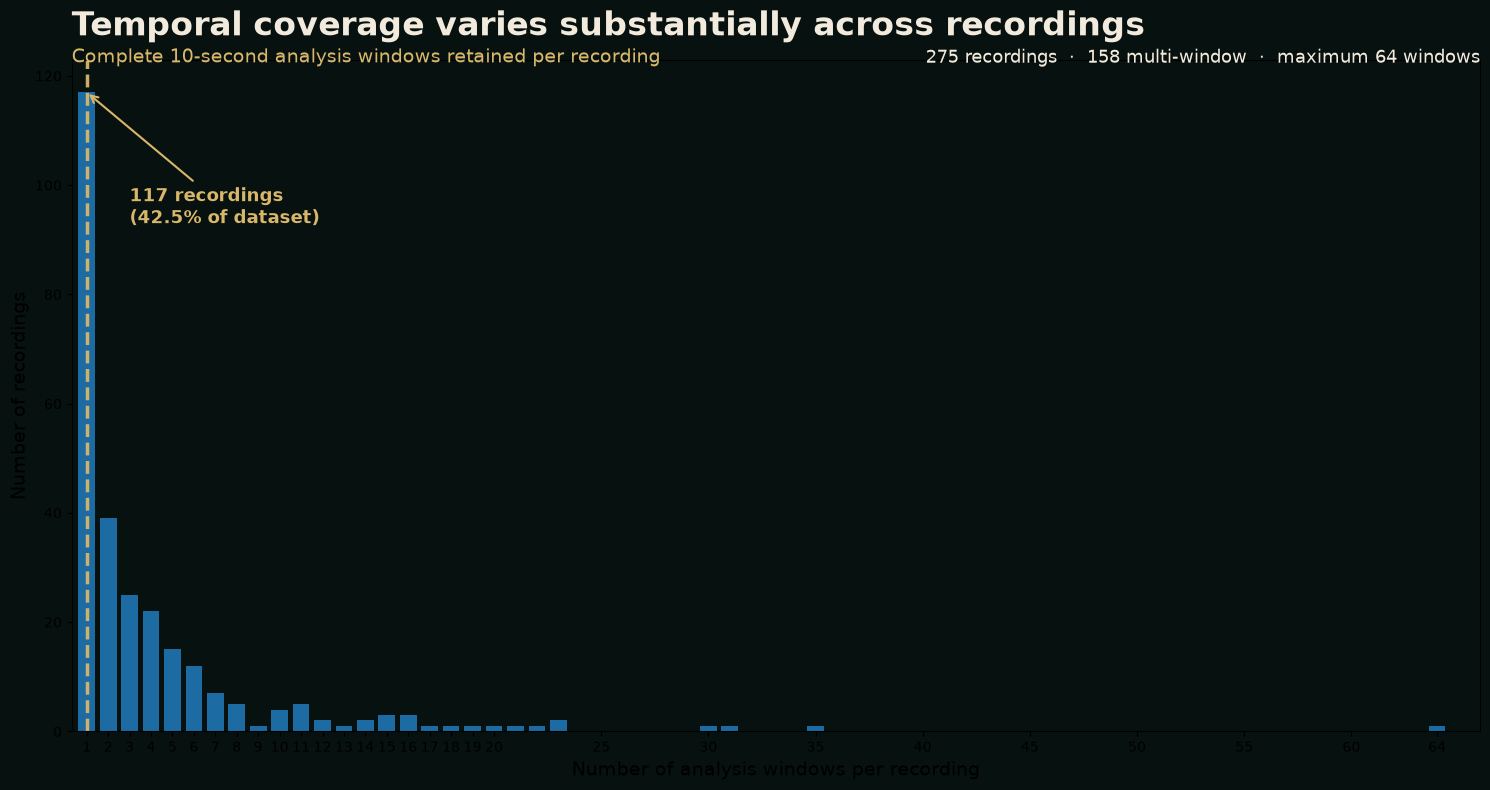

In [41]:
# ============================================================
# 26. Figure 13 — Analysis-window structure
# ============================================================

window_counts = (
    features_eda["n_windows"]
    .value_counts()
    .sort_index()
)

single_count = int(
    features_eda["single_window"].astype(bool).sum()
)

multi_count = int(
    (~features_eda["single_window"].astype(bool)).sum()
)

total_recordings = len(features_eda)
max_windows = int(features_eda["n_windows"].max())

single_pct = 100 * single_count / total_recordings

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

ax.bar(
    window_counts.index,
    window_counts.values,
    width=0.78,
    alpha=0.9
)

# ------------------------------------------------------------
# Highlight single-window recordings
# ------------------------------------------------------------

ax.axvline(
    1,
    color=EDA_STYLE["gold"],
    linestyle="--",
    linewidth=2.5,
    alpha=0.95
)

ax.annotate(
    f"{single_count} recordings\n"
    f"({single_pct:.1f}% of dataset)",
    xy=(1, window_counts.loc[1]),
    xytext=(3.0, window_counts.max() * 0.82),
    color=EDA_STYLE["gold"],
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        color=EDA_STYLE["gold"],
        lw=1.5
    )
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Temporal coverage varies substantially across recordings",
    loc="left",
    fontsize=24,
    fontweight="bold",
    color=EDA_STYLE["foreground"],
    pad=18
)

ax.text(
    0,
    0.99,
    "Complete 10-second analysis windows retained per recording",
    transform=ax.transAxes,
    fontsize=14,
    color=EDA_STYLE["gold"],
    va="bottom"
)

ax.text(
    1,
    0.99,
    f"{total_recordings} recordings  ·  "
    f"{multi_count} multi-window  ·  "
    f"maximum {max_windows} windows",
    transform=ax.transAxes,
    fontsize=13,
    color=EDA_STYLE["foreground"],
    ha="right",
    va="bottom"
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Number of analysis windows per recording",
    fontsize=14
)

ax.set_ylabel(
    "Number of recordings",
    fontsize=14
)

# Show common values clearly, then selected tail values
max_display = max_windows

if max_display > 20:
    ticks = list(range(1, 21)) + [
        x for x in [25, 30, 35, 40, 45, 50, 55, 60, 64]
        if x <= max_display
    ]
else:
    ticks = list(range(1, max_display + 1))

ax.set_xticks(ticks)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

def style_axis(ax):
    ax.set_facecolor(EDA_STYLE["background"])

    # Spines
    for spine in ax.spines.values():
        spine.set_color(EDA_STYLE["grid"])

    # Grid
    ax.grid(
        True,
        color=EDA_STYLE["grid"],
        alpha=0.55,
        linewidth=0.8
    )

    # Tick labels
    ax.tick_params(
        axis="both",
        colors=EDA_STYLE["foreground"],
        labelsize=11
    )

    # Axis labels
    ax.xaxis.label.set_color(
        EDA_STYLE["foreground"]
    )
    ax.yaxis.label.set_color(
        EDA_STYLE["foreground"]
    )

    # Title
    ax.title.set_color(
        EDA_STYLE["foreground"]
    )

# Make the long tail easier to see without distorting the
# actual values.
ax.set_xlim(0.3, max_windows + 2)

plt.tight_layout()

save_eda_figure(
    fig,
    "13_window_structure.png"
)

plt.show()

**Figure interpretation.** Of 275 recordings, 117 (42.5%) contained only a single 10-second analysis window, meaning within-recording variability could not be estimated for these cases. This is why single-window standard-deviation features were explicitly set to zero with an accompanying indicator column, rather than left as missing values, during feature extraction.

In [42]:
# ============================================================
# 27A. Inspect eBird species/state columns
# ============================================================

print("eBird columns")
print("=" * 60)

for i, col in enumerate(ebird.columns):
    print(i, col)

print("\nLikely species-related columns:")
for col in ebird.columns:
    if any(
        term in col.lower()
        for term in ["species", "scientific", "common", "code", "taxon"]
    ):
        print(" ", col)

print("\nState column:")
print("state" in ebird.columns)

eBird columns
0 state
1 species_code
2 common_name
3 scientific_name
4 location_id
5 location_name
6 observation_datetime
7 how_many
8 latitude
9 longitude
10 observation_valid
11 observation_reviewed
12 location_private
13 submission_id
14 observation_datetime_original
15 observation_date
16 year
17 month
18 day_of_year
19 hour
20 minute
21 has_observation_time
22 season
23 coordinate_valid
24 state_bbox_match
25 geographic_note
26 flag_missing_count
27 flag_missing_time
28 flag_pelagic
29 flag_any
30 cleaning_action
31 cleaning_reason

Likely species-related columns:
  species_code
  common_name
  scientific_name

State column:
True


In [43]:
# ============================================================
# 27. Cross-source sampling coverage audit
# ============================================================

print("CROSS-SOURCE SAMPLING COVERAGE")
print("=" * 60)

# ------------------------------------------------------------
# Xeno-canto acoustic sample
# ------------------------------------------------------------

xc_coverage = (
    features_eda
    .groupby("state")
    .agg(
        acoustic_recordings=("recording_id", "nunique"),
        acoustic_species=("species_id", "nunique")
    )
    .reset_index()
)

# ------------------------------------------------------------
# eBird independent observation sample
# Scientific name is used as the common species identifier
# ------------------------------------------------------------

ebird_coverage = (
    ebird
    .groupby("state")
    .agg(
        ebird_observations=("scientific_name", "size"),
        ebird_species=("scientific_name", "nunique")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Merge the two sampling summaries
# ------------------------------------------------------------

coverage = (
    xc_coverage
    .merge(
        ebird_coverage,
        on="state",
        how="outer"
    )
    .sort_values("state")
)

print("\nCoverage by state:")
print(coverage.to_string(index=False))

# ------------------------------------------------------------
# Overall coverage
# ------------------------------------------------------------

print("\nOVERALL")
print("-" * 60)

print(
    "Xeno-canto recordings:",
    features_eda["recording_id"].nunique()
)

print(
    "Xeno-canto represented species:",
    features_eda["species_id"].nunique()
)

print(
    "eBird observations:",
    len(ebird)
)

print(
    "eBird represented species:",
    ebird["scientific_name"].nunique()
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert set(coverage["state"]) == {"AZ", "CA", "TX"}

assert (
    coverage["acoustic_recordings"].sum()
    == features_eda["recording_id"].nunique()
)

assert (
    coverage["ebird_observations"].sum()
    == len(ebird)
)

print("\nCoverage audit passed.")

CROSS-SOURCE SAMPLING COVERAGE

Coverage by state:
state  acoustic_recordings  acoustic_species  ebird_observations  ebird_species
   AZ                   75                44                 373            373
   CA                  100                66                 495            495
   TX                  100               100                 458            458

OVERALL
------------------------------------------------------------
Xeno-canto recordings: 275
Xeno-canto represented species: 159
eBird observations: 1326
eBird represented species: 675

Coverage audit passed.


CROSS-SOURCE SAMPLING COVERAGE

Coverage by state:
       acoustic_recordings  acoustic_species  ebird_observations  \
state                                                              
AZ                      75                44                 373   
CA                     100                66                 495   
TX                     100               100                 458   

       ebird_species  
state                 
AZ               373  
CA               495  
TX               458  

OVERALL
------------------------------------------------------------
Xeno-canto recordings: 275
Xeno-canto represented species: 159
eBird observations: 1326
eBird represented species: 675
Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\02_species_coverage.png


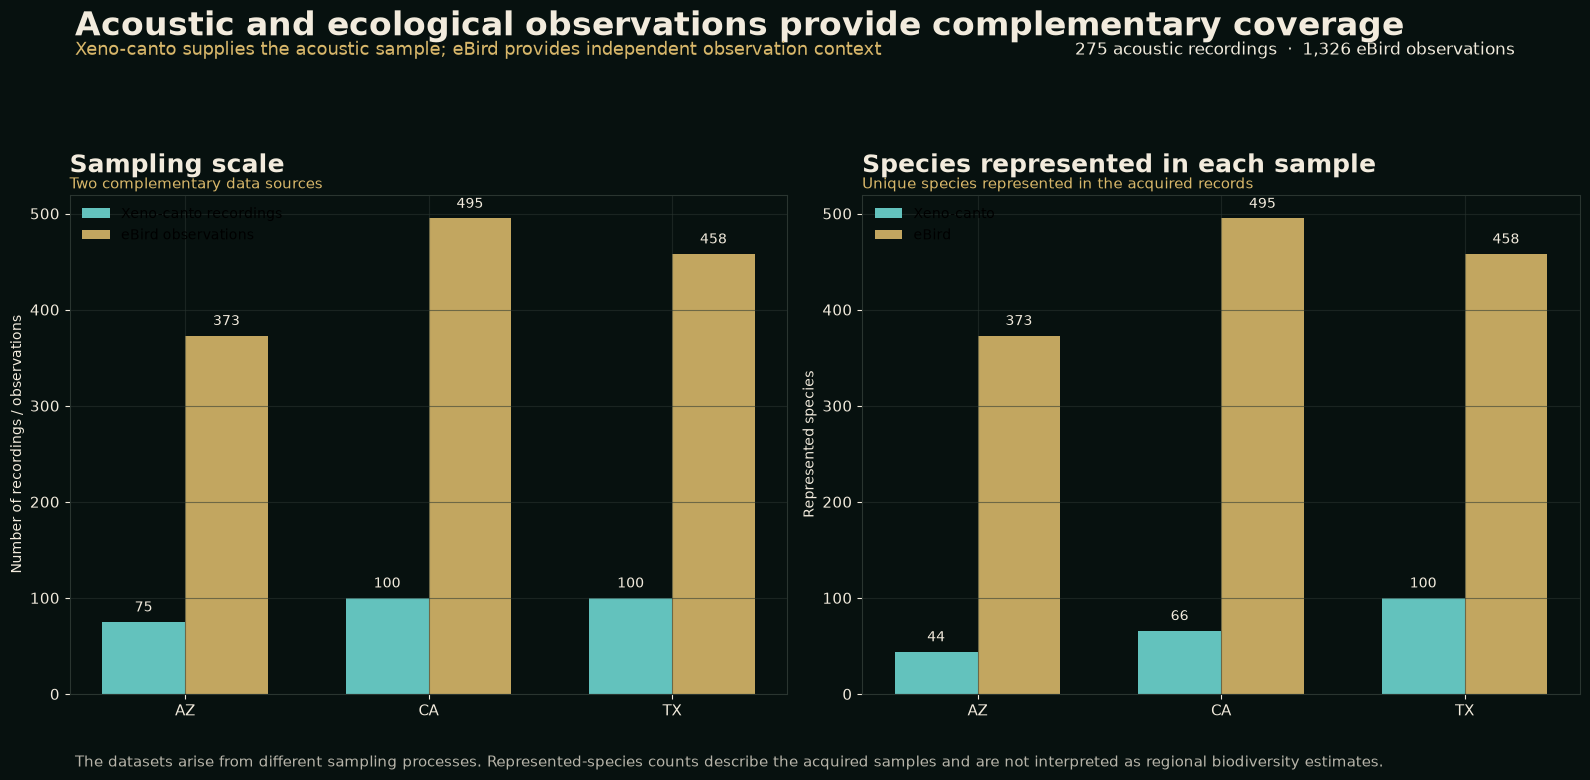

In [44]:
# ============================================================
# FIGURE 02 — CROSS-SOURCE SAMPLING COVERAGE
# ============================================================

# ------------------------------------------------------------
# 1. Acoustic coverage
# ------------------------------------------------------------

acoustic_coverage = (
    features_eda
    .groupby("state")
    .agg(
        acoustic_recordings=("recording_id", "nunique"),
        acoustic_species=("species_id", "nunique")
    )
)

# ------------------------------------------------------------
# 2. eBird coverage
# ------------------------------------------------------------

ebird_coverage = (
    ebird
    .groupby("state")
    .agg(
        ebird_observations=("scientific_name", "size"),
        ebird_species=("scientific_name", "nunique")
    )
)

# ------------------------------------------------------------
# 3. Combine coverage summaries
# ------------------------------------------------------------

coverage = (
    acoustic_coverage
    .join(ebird_coverage, how="outer")
    .fillna(0)
    .loc[["AZ", "CA", "TX"]]
)

print("CROSS-SOURCE SAMPLING COVERAGE")
print("=" * 60)

print("\nCoverage by state:")
print(coverage)

print("\nOVERALL")
print("-" * 60)

print(
    f"Xeno-canto recordings: "
    f"{features_eda['recording_id'].nunique()}"
)

print(
    f"Xeno-canto represented species: "
    f"{features_eda['species_id'].nunique()}"
)

print(
    f"eBird observations: "
    f"{len(ebird)}"
)

print(
    f"eBird represented species: "
    f"{ebird['scientific_name'].nunique()}"
)


# ------------------------------------------------------------
# 4. Plotting data
# ------------------------------------------------------------

states = ["AZ", "CA", "TX"]

acoustic_recordings = coverage.loc[
    states, "acoustic_recordings"
].to_numpy()

ebird_observations = coverage.loc[
    states, "ebird_observations"
].to_numpy()

acoustic_species = coverage.loc[
    states, "acoustic_species"
].to_numpy()

ebird_species = coverage.loc[
    states, "ebird_species"
].to_numpy()


# ------------------------------------------------------------
# 5. Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

ax1, ax2 = axes

x = np.arange(len(states))
width = 0.34


# ============================================================
# PANEL A — SAMPLING SCALE
# ============================================================

bars_acoustic = ax1.bar(
    x - width / 2,
    acoustic_recordings,
    width,
    label="Xeno-canto recordings",
    color=EDA_STYLE["cyan"],
    alpha=0.90
)

bars_ebird = ax1.bar(
    x + width / 2,
    ebird_observations,
    width,
    label="eBird observations",
    color=EDA_STYLE["gold"],
    alpha=0.90
)

ax1.set_title(
    "Sampling scale",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color=EDA_STYLE["foreground"],
    pad=16
)

ax1.text(
    0,
    1.005,
    "Two complementary data sources",
    transform=ax1.transAxes,
    fontsize=11,
    color=EDA_STYLE["gold"],
    ha="left",
    va="bottom"
)

ax1.set_ylabel(
    "Number of recordings / observations",
    color=EDA_STYLE["foreground"]
)

ax1.set_xticks(x)
ax1.set_xticklabels(states)

ax1.legend(
    frameon=False,
    loc="upper left"
)

style_axis(ax1)


# Value labels
label_offset_left = max(ebird_observations) * 0.015

for bars in [bars_acoustic, bars_ebird]:

    for bar in bars:

        height = bar.get_height()

        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + label_offset_left,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=EDA_STYLE["foreground"]
        )


# ============================================================
# PANEL B — SPECIES REPRESENTED
# ============================================================

bars_acoustic_species = ax2.bar(
    x - width / 2,
    acoustic_species,
    width,
    label="Xeno-canto",
    color=EDA_STYLE["cyan"],
    alpha=0.90
)

bars_ebird_species = ax2.bar(
    x + width / 2,
    ebird_species,
    width,
    label="eBird",
    color=EDA_STYLE["gold"],
    alpha=0.90
)

ax2.set_title(
    "Species represented in each sample",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color=EDA_STYLE["foreground"],
    pad=16
)

ax2.text(
    0,
    1.005,
    "Unique species represented in the acquired records",
    transform=ax2.transAxes,
    fontsize=11,
    color=EDA_STYLE["gold"],
    ha="left",
    va="bottom"
)

ax2.set_ylabel(
    "Represented species",
    color=EDA_STYLE["foreground"]
)

ax2.set_xticks(x)
ax2.set_xticklabels(states)

ax2.legend(
    frameon=False,
    loc="upper left"
)

style_axis(ax2)


# Value labels
label_offset_right = max(ebird_species) * 0.015

for bars in [bars_acoustic_species, bars_ebird_species]:

    for bar in bars:

        height = bar.get_height()

        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            height + label_offset_right,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=EDA_STYLE["foreground"]
        )


# ============================================================
# FIGURE-LEVEL TITLE
# ============================================================

fig.suptitle(
    "Acoustic and ecological observations provide complementary coverage",
    fontsize=24,
    fontweight="bold",
    color=EDA_STYLE["foreground"],
    x=0.05,
    y=0.975,
    ha="left"
)

fig.text(
    0.05,
    0.925,
    "Xeno-canto supplies the acoustic sample; eBird provides independent observation context",
    fontsize=13,
    color=EDA_STYLE["gold"],
    ha="left",
    va="center"
)

fig.text(
    0.95,
    0.925,
    "275 acoustic recordings  ·  1,326 eBird observations",
    fontsize=12,
    color=EDA_STYLE["foreground"],
    ha="right",
    va="center"
)


# ============================================================
# SCIENTIFIC INTERPRETATION NOTE
# ============================================================

fig.text(
    0.05,
    0.025,
    "The datasets arise from different sampling processes. "
    "Represented-species counts describe the acquired samples and are not "
    "interpreted as regional biodiversity estimates.",
    fontsize=10.5,
    color=EDA_STYLE["foreground"],
    alpha=0.75,
    ha="left",
    va="bottom"
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0.07, 1, 0.875]
)

save_eda_figure(
    fig,
    "02_species_coverage.png"
)

plt.show()

In [45]:
# ============================================================
# Export richness comparison for the website (interactive chart)
# ============================================================

richness_comparison = (
    coverage
    .reset_index()
    .loc[:, ["state", "acoustic_recordings", "acoustic_species",
             "ebird_observations", "ebird_species"]]
)
richness_comparison["acoustic_representation_pct"] = (
    richness_comparison["acoustic_species"]
    / richness_comparison["ebird_species"] * 100
).round(1)

richness_json_path = WEBSITE_DATA_DIR / "richness_comparison.json"
richness_comparison.to_json(richness_json_path, orient="records", indent=2)

print("Saved:", richness_json_path)
print(richness_comparison.to_string(index=False))


Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\website\public\data\richness_comparison.json
state  acoustic_recordings  acoustic_species  ebird_observations  ebird_species  acoustic_representation_pct
   AZ                   75                44                 373            373                         11.8
   CA                  100                66                 495            495                         13.3
   TX                  100               100                 458            458                         21.8


In [46]:
# ============================================================
# 23. Geographic distribution audit
# ============================================================

print("GEOGRAPHIC DISTRIBUTION AUDIT")
print("=" * 60)


# ------------------------------------------------------------
# 1. Required columns
# ------------------------------------------------------------

feature_geo_keys = [
    "recording_id",
    "state",
    "species_id"
]

metadata_geo_columns = [
    "recording_id",
    "latitude",
    "longitude"
]

missing_feature_columns = [
    col for col in feature_geo_keys
    if col not in features_eda.columns
]

missing_metadata_columns = [
    col for col in metadata_geo_columns
    if col not in master_metadata.columns
]

print("Missing feature columns:")
print(missing_feature_columns)

print("\nMissing metadata geographic columns:")
print(missing_metadata_columns)

assert len(missing_feature_columns) == 0
assert len(missing_metadata_columns) == 0


# ------------------------------------------------------------
# 2. Build dedicated geographic dataframe
# ------------------------------------------------------------

geo_df = (
    features_eda[
        feature_geo_keys
    ]
    .merge(
        master_metadata[
            metadata_geo_columns
        ],
        on="recording_id",
        how="left",
        validate="one_to_one"
    )
)

print("\nGeographic dataframe:")
print(f"Rows: {len(geo_df)}")
print(f"Columns: {len(geo_df.columns)}")


# ------------------------------------------------------------
# 3. Provenance validation
# ------------------------------------------------------------

assert len(geo_df) == len(features_eda)

assert (
    geo_df["recording_id"].nunique()
    == features_eda["recording_id"].nunique()
)

assert (
    geo_df["recording_id"].isna().sum()
    == 0
)

print("\nRecording identity:")
print(
    f"Unique recordings: "
    f"{geo_df['recording_id'].nunique()}"
)


# ------------------------------------------------------------
# 4. Coordinate completeness
# ------------------------------------------------------------

missing_latitude = geo_df["latitude"].isna().sum()
missing_longitude = geo_df["longitude"].isna().sum()

print("\nCoordinate completeness:")
print(f"Missing latitude:  {missing_latitude}")
print(f"Missing longitude: {missing_longitude}")


# ------------------------------------------------------------
# 5. Coordinate ranges
# ------------------------------------------------------------

print("\nCoordinate ranges:")

print(
    f"Latitude:  "
    f"{geo_df['latitude'].min():.4f} "
    f"to "
    f"{geo_df['latitude'].max():.4f}"
)

print(
    f"Longitude: "
    f"{geo_df['longitude'].min():.4f} "
    f"to "
    f"{geo_df['longitude'].max():.4f}"
)


# ------------------------------------------------------------
# 6. Coordinate validity
# ------------------------------------------------------------

invalid_latitude = (
    (geo_df["latitude"] < -90) |
    (geo_df["latitude"] > 90)
).sum()

invalid_longitude = (
    (geo_df["longitude"] < -180) |
    (geo_df["longitude"] > 180)
).sum()

print("\nCoordinate validity:")
print(f"Invalid latitude:  {invalid_latitude}")
print(f"Invalid longitude: {invalid_longitude}")


# ------------------------------------------------------------
# 7. Geographic summary by state
# ------------------------------------------------------------

geo_summary = (
    geo_df
    .groupby("state")
    .agg(
        recordings=("recording_id", "nunique"),
        unique_species=("species_id", "nunique"),
        min_latitude=("latitude", "min"),
        max_latitude=("latitude", "max"),
        min_longitude=("longitude", "min"),
        max_longitude=("longitude", "max")
    )
)

print("\nGeographic summary by state:")
print(geo_summary)


# ------------------------------------------------------------
# 8. Exact duplicate coordinates
# ------------------------------------------------------------

duplicate_coordinates = (
    geo_df
    .groupby(
        ["latitude", "longitude"]
    )
    .size()
    .reset_index(
        name="recording_count"
    )
    .query("recording_count > 1")
    .sort_values(
        "recording_count",
        ascending=False
    )
)

print("\nExact duplicate coordinates:")
print(
    f"{len(duplicate_coordinates)} "
    "coordinate locations contain multiple recordings."
)

if len(duplicate_coordinates) > 0:
    print(
        duplicate_coordinates.head(10)
    )


# ------------------------------------------------------------
# 9. State consistency
# ------------------------------------------------------------

state_counts = (
    geo_df["state"]
    .value_counts()
    .sort_index()
)

print("\nRecordings by state:")
print(state_counts)


# ------------------------------------------------------------
# 10. Final audit
# ------------------------------------------------------------

assert missing_latitude == 0
assert missing_longitude == 0
assert invalid_latitude == 0
assert invalid_longitude == 0

assert set(
    geo_df["state"].dropna().unique()
) == {"AZ", "CA", "TX"}

print("\nGeographic audit passed.")

GEOGRAPHIC DISTRIBUTION AUDIT
Missing feature columns:
[]

Missing metadata geographic columns:
[]

Geographic dataframe:
Rows: 275
Columns: 5

Recording identity:
Unique recordings: 275

Coordinate completeness:
Missing latitude:  0
Missing longitude: 0

Coordinate ranges:
Latitude:  25.8199 to 41.9927
Longitude: -124.2411 to -93.5284

Coordinate validity:
Invalid latitude:  0
Invalid longitude: 0

Geographic summary by state:
       recordings  unique_species  min_latitude  max_latitude  min_longitude  \
state                                                                          
AZ             75              44       31.3400       34.6038      -114.0690   
CA            100              66       32.5440       41.9927      -124.2411   
TX            100             100       25.8199       36.4775      -106.6146   

       max_longitude  
state                 
AZ         -109.0250  
CA         -114.4516  
TX          -93.5284  

Exact duplicate coordinates:
38 coordinate location

GEOGRAPHIC DISTRIBUTION
state
AZ     75
CA    100
TX    100
Name: recording_id, dtype: int64

Total recording locations: 275
Saved: C:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\eda\03_recording_map.png


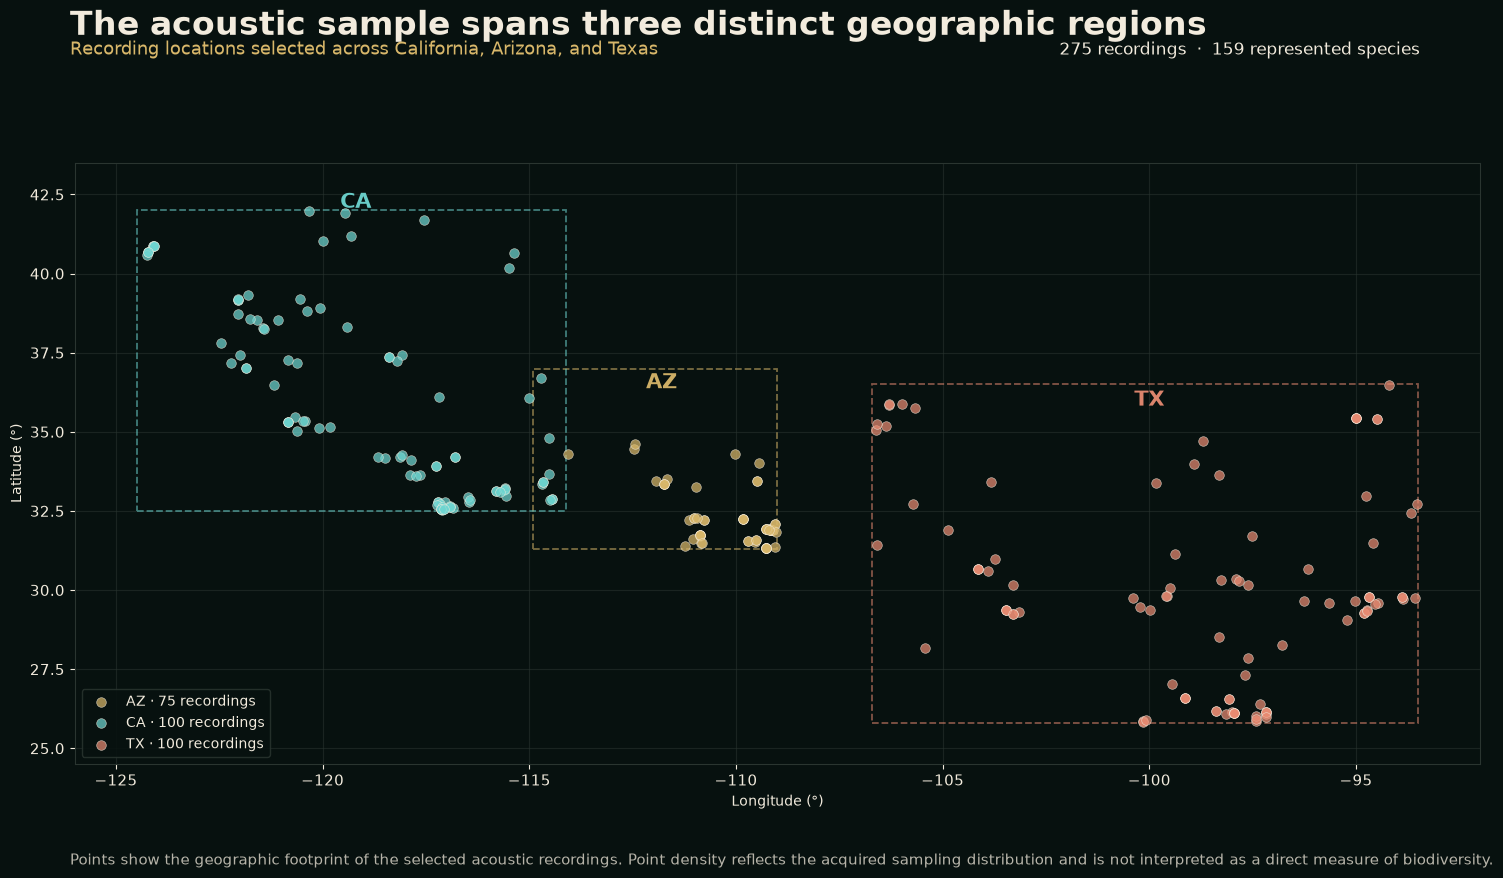

In [47]:
# ============================================================
# FIGURE 03 — GEOGRAPHIC DISTRIBUTION
# ============================================================

# ------------------------------------------------------------
# 1. Validate geographic dataframe
# ------------------------------------------------------------

assert len(geo_df) == 275
assert geo_df["latitude"].notna().all()
assert geo_df["longitude"].notna().all()

print("GEOGRAPHIC DISTRIBUTION")
print("=" * 60)

print(
    geo_df.groupby("state")["recording_id"]
    .nunique()
    .sort_index()
)

print(
    f"\nTotal recording locations: "
    f"{geo_df['recording_id'].nunique()}"
)


# ------------------------------------------------------------
# 2. Study-region coordinate boxes
# ------------------------------------------------------------

# These are the same broad geographic boxes used during
# Xeno-canto acquisition. They are shown as study-region
# extents, not political state boundaries.

region_boxes = {
    "CA": {
        "lon_min": -124.5,
        "lon_max": -114.1,
        "lat_min": 32.5,
        "lat_max": 42.0
    },
    "AZ": {
        "lon_min": -114.9,
        "lon_max": -109.0,
        "lat_min": 31.3,
        "lat_max": 37.0
    },
    "TX": {
        "lon_min": -106.7,
        "lon_max": -93.5,
        "lat_min": 25.8,
        "lat_max": 36.5
    }
}


# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 9)
)

# ------------------------------------------------------------
# 4. Plot recording locations
# ------------------------------------------------------------

state_order = ["AZ", "CA", "TX"]

state_colors = {
    "AZ": EDA_STYLE["gold"],
    "CA": EDA_STYLE["cyan"],
    "TX": EDA_STYLE["coral"]
}

for state in state_order:

    subset = geo_df[
        geo_df["state"] == state
    ]

    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        s=48,
        alpha=0.72,
        color=state_colors[state],
        edgecolor=EDA_STYLE["foreground"],
        linewidth=0.45,
        label=f"{state} · {len(subset)} recordings",
        zorder=3
    )


# ------------------------------------------------------------
# 5. Add study-region bounding boxes
# ------------------------------------------------------------

for state in state_order:

    box = region_boxes[state]

    width = box["lon_max"] - box["lon_min"]
    height = box["lat_max"] - box["lat_min"]

    rectangle = plt.Rectangle(
        (
            box["lon_min"],
            box["lat_min"]
        ),
        width,
        height,
        fill=False,
        edgecolor=state_colors[state],
        linewidth=1.3,
        linestyle="--",
        alpha=0.55,
        zorder=2
    )

    ax.add_patch(rectangle)


# ------------------------------------------------------------
# 6. Region labels
# ------------------------------------------------------------

region_label_positions = {
    "AZ": (-111.8, 36.55),
    "CA": (-119.2, 42.25),
    "TX": (-100.0, 36.0)
}

for state, (lon, lat) in region_label_positions.items():

    ax.text(
        lon,
        lat,
        state,
        fontsize=15,
        fontweight="bold",
        color=state_colors[state],
        ha="center",
        va="center",
        alpha=0.95,
        zorder=4
    )


# ------------------------------------------------------------
# 7. Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Longitude (°)",
    color=EDA_STYLE["foreground"]
)

ax.set_ylabel(
    "Latitude (°)",
    color=EDA_STYLE["foreground"]
)

ax.set_xlim(-126, -92)
ax.set_ylim(24.5, 43.5)

style_axis(ax)


# ------------------------------------------------------------
# 8. Figure title
# ------------------------------------------------------------

fig.suptitle(
    "The acoustic sample spans three distinct geographic regions",
    fontsize=24,
    fontweight="bold",
    color=EDA_STYLE["foreground"],
    x=0.05,
    y=0.975,
    ha="left"
)

fig.text(
    0.05,
    0.925,
    "Recording locations selected across California, Arizona, and Texas",
    fontsize=13,
    color=EDA_STYLE["gold"],
    ha="left"
)

fig.text(
    0.95,
    0.925,
    "275 recordings  ·  159 represented species",
    fontsize=12,
    color=EDA_STYLE["foreground"],
    ha="right"
)


# ------------------------------------------------------------
# 9. Legend
# ------------------------------------------------------------

legend = ax.legend(
    loc="lower left",
    frameon=True,
    framealpha=0.85,
    facecolor=EDA_STYLE["background"],
    edgecolor=EDA_STYLE["grid"],
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(EDA_STYLE["foreground"])


# ------------------------------------------------------------
# 10. Scientific interpretation note
# ------------------------------------------------------------

fig.text(
    0.05,
    0.025,
    "Points show the geographic footprint of the selected acoustic recordings. "
    "Point density reflects the acquired sampling distribution and is not "
    "interpreted as a direct measure of biodiversity.",
    fontsize=10.5,
    color=EDA_STYLE["foreground"],
    alpha=0.75,
    ha="left"
)


# ------------------------------------------------------------
# 11. Save
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.07, 1, 0.875]
)

save_eda_figure(
    fig,
    "03_recording_map.png"
)

plt.show()

**Figure interpretation.** Recording locations cluster within each state's acquisition bounding box, with no points falling outside their assigned region — confirming the geographic validation performed during data auditing. Point density reflects the acquired sampling distribution and is not interpreted as a direct measure of regional biodiversity.